In [1]:
import xarray as xr
import numpy as np
# Open the dataset
ds = xr.open_dataset("/Users/abhimanyu/Desktop/s2s/data/processed/s2s_reforecast_sorted.nc")

# Remove the first step (index 0) from the dataset
ds_ecm = ds.isel(step=slice(1, None))

# You can check the new step values to confirm step 0 is gone
print("Remaining steps:", ds_ecm.step.values)

# If you want to check the precipitation values again for the first 10 dates (now starting at what was previously step 1)
tp_subset = ds_ecm['total_precipitation'].isel(time=slice(0, 10), step=0)
tp_values = tp_subset.values
print("Non-NaN values at new first step:")
print(tp_values[~np.isnan(tp_values)])


Remaining steps: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42]
Non-NaN values at new first step:
[1.765625   2.895996   1.6640625  ... 1.2919922  0.04296875 0.0234375 ]


In [2]:
import sys
sys.path.append('..')
import os
from scripts.xarray_utils import (analyze_netcdf, zarr_to_netcdf, find_missing_days)
import xarray as xr
import pandas as pd 
import numpy as np  

ds_big = xr.open_zarr("/Users/abhimanyu/Downloads/IFS_reforecast_download-main/s2s_new_vars_sorted.zarr")
ds_imd = xr.open_zarr("/Users/abhimanyu/Desktop/s2s/data/raw/IMD_rainfall_0p25.zarr")
ds_imd = ds_imd.where(ds_imd != -999)
ds_ecm = ds_ecm
#valid_time conversion
step_td = pd.to_timedelta(ds_ecm.step.values, unit='D').to_numpy()

ds_ecmf = ds_ecm.assign_coords(
    valid_time = (('time', 'step'),
    ds_ecm.time.values[:, None] + step_td[None, :])
)

In [13]:
# %%
# ============ CELL 1: CONFIG ============
# The only cell you edit between experiments.

import numpy as np

DTYPE = np.float32
IMD_TARGET_VAR = "rain"

# --- data / windows ---
WINDOWS = [("week2", 8, 14), ("week3_4", 15, 28), ("week5_6", 29, 42)]
MONTHS = None                  # None = full year; (6,7,8,9) = JJAS only
COARSE_PAD = 3.0                # degrees of margin around the IMD box for encoder A
CLIM_WINDOW_DAYS = 7            # +/- days pooled when building a day-of-year climatology
TEST_YEARS_N = 3                # held out of every fold, never trained on

BIG_VARS = ["top_net_thermal_radiation", "geopotential_height_200",
            "geopotential_height_500", "geopotential_height_850",
            "geopotential_height_1000"]

# --- model / training ---
BASE = 24
DROP = 0.2
BATCH = 16
EPOCHS = 60
LR = 2e-4
WD = 1e-3
PATIENCE = 10
FOLDS = 5

# --- heads ---
USE_TERCILE = False       # 3-class head, scored by RPSS
USE_DETERM = True        # 1-value head (mm/day anomaly), scored by skill/ACC
W_CE, W_MSE = 1.0, 1.0   # loss weights when both heads are on
LABEL_SMOOTH = 0.0

# --- loss shaping ---
# "mse"              plain masked squared error -- the baseline
# "extreme_weighted" upweight cells by how extreme the TRUE anomaly is there,
#                    measured in that cell's own sigma so "extreme" means the
#                    same thing in Kerala and in Rajasthan
LOSS_KIND = "extreme_weighted"
EXTREME_ALPHA = 2.0      # weight = 1 + alpha * |target| / sigma_cell; a 3-sigma
                         # event gets 1 + 2*3 = 7x at alpha=2
SIGMA_FLOOR_QUANTILE = 0.10   # floor sigma at this quantile of the valid cells,
                              # so a near-zero-variance arid cell cannot earn a
                              # huge weight from a trivially small anomaly

# --- metric guards ---
# Skill is a ratio, so a cell whose observed anomaly barely varies can produce
# an arbitrarily large negative value and dominate a domain mean. Cells whose
# climatological RMSE is below this (mm/day) are excluded from skill entirely.
SKILL_MIN_CLIM_RMSE = 0.05

# --- paths ---
TAG = ("prob" + ("_t" if USE_TERCILE else "") + ("_d" if USE_DETERM else "")
       + (f"_x{EXTREME_ALPHA:g}" if LOSS_KIND == "extreme_weighted" else ""))
CACHE = "unet_cache_prob"          # directory written by prepare_dual_pipeline
OUT_MAPS = f"unet_{TAG}.nc"

print(f"TAG={TAG} | tercile={USE_TERCILE} determ={USE_DETERM} | "
      f"loss={LOSS_KIND} | months={MONTHS}")


# %%
# ============ CELL 2: UTILS ============

import time
from contextlib import contextmanager


@contextmanager
def stage(name):
    """Prints a start/done line with elapsed time around a block of work."""
    print(f"[ ] {name} ...", flush=True)
    started = time.perf_counter()
    yield
    print(f"[x] {name}  ({time.perf_counter() - started:.1f}s)", flush=True)


# %%
# ============ CELL 3: CLIMATOLOGY AND TERCILES ============
# Everything here takes `train_rows` = the current fold's TRAINING samples
# only. Computing a climatology or a tercile edge from validation years would
# let the model "see" the answer before being tested on it.

# --- 1. day-of-year climatology ---

def day_of_year_window_matrix(center_doys, window_days):
    """Boolean matrix (366, n_samples): row d is True for every sample whose
    center day-of-year is within `window_days` of calendar day d+1.

    Distance wraps around the year end, so Dec 30 counts as close to Jan 2.
    """
    calendar_days = np.arange(1, 367)
    distance = np.abs(center_doys[None, :].astype(int) - calendar_days[:, None])
    distance = np.minimum(distance, 366 - distance)
    return distance <= window_days


def climatology_by_day_of_year(values, center_doys, train_rows, window_days,
                               cell_chunk=20000):
    """(n_samples, ...) -> (366, ...): the average value near each calendar day,
    using only `train_rows`, pooled the same way for every day of the year.

    Chunked over the flattened spatial axis so a big field (e.g. 129x135
    lat/lon) is never fully duplicated in memory by the isfinite/where steps
    below -- doing it in one shot on a large array is what blew up RAM before.
    """
    shape_per_sample = values.shape[1:]
    flat = values[train_rows].reshape(int(np.sum(train_rows)), -1)
    n_cells = flat.shape[1]

    pooling_matrix = day_of_year_window_matrix(
        center_doys[train_rows], window_days).astype(DTYPE)

    climatology = np.empty((366, n_cells), DTYPE)
    for start in range(0, n_cells, cell_chunk):
        stop = min(start + cell_chunk, n_cells)
        block = flat[:, start:stop]
        is_valid = np.isfinite(block)

        sample_count = pooling_matrix @ is_valid.astype(DTYPE)
        value_sum = pooling_matrix @ np.where(is_valid, block, 0).astype(DTYPE)

        with np.errstate(invalid="ignore", divide="ignore"):
            climatology[:, start:stop] = np.where(
                sample_count > 0, value_sum / np.maximum(sample_count, 1), np.nan)

    return climatology.reshape((366,) + shape_per_sample)


# --- 2. anomalies ---

def remove_climatology(values, center_doys, train_rows, window_days=CLIM_WINDOW_DAYS):
    """Subtract each sample's day-of-year climatology. Keeps NaN, keeps units."""
    climatology = climatology_by_day_of_year(values, center_doys, train_rows, window_days)
    return values - climatology[center_doys - 1]


def standardize_channels(anomaly, train_rows):
    """Zero mean, unit std per channel (axis 1), using train rows only.
    NaN -> 0 after standardizing, so the network never sees a NaN input.
    """
    mean = np.nanmean(anomaly[train_rows], axis=(0, 2, 3), keepdims=True)
    std = np.nanstd(anomaly[train_rows], axis=(0, 2, 3), keepdims=True)
    std = np.where(std < 1e-8, 1.0, std)      # a dead channel divides by 1, not 0
    return np.nan_to_num((anomaly - mean) / std).astype(DTYPE)


def anomalise_predictors(values, center_doys, train_rows):
    """Predictor pipeline: de-seasonalise, then standardise. Used for XA/XB."""
    anomaly = remove_climatology(values, center_doys, train_rows)
    return standardize_channels(anomaly, train_rows)


def anomalise_target(values, center_doys, train_rows):
    """Target pipeline: de-seasonalise only. Kept in real units (mm/day) with
    NaN preserved, because the mask and the tercile edges both depend on it.
    """
    return remove_climatology(values, center_doys, train_rows).astype(DTYPE)


# --- 3. per-cell spread ---

def anomaly_std_per_cell(target_anomaly, train_rows, valid_mask,
                         floor_quantile=SIGMA_FLOOR_QUANTILE):
    """Per-cell standard deviation of the target anomaly, train rows only.

    The denominator that makes the extreme-weighted loss mean the same thing
    everywhere. Without it, "|target| is large" just means "this cell is wet on
    average", and a handful of Ghats cells at +-15 mm/day would take over the
    loss while the arid northwest is effectively unweighted.

    Sigma is floored at a low quantile of the valid cells. A cell whose anomaly
    barely varies -- the dry northwest belt, high-altitude Himalayan cells --
    would otherwise turn a trivially small anomaly into an enormous weight,
    which is the same low-variance trap that inflates ACC there.
    """
    with np.errstate(invalid="ignore"):
        sigma = np.nanstd(target_anomaly[train_rows], axis=0).astype(DTYPE)

    floor = float(np.nanquantile(sigma[valid_mask], floor_quantile))
    return np.where(valid_mask, np.maximum(sigma, floor), 1.0).astype(DTYPE)


# --- 4. terciles ---

def tercile_edges(target_anomaly, train_rows, valid_mask, cell_chunk=20000):
    """Per-cell 33rd/67th percentile of the target anomaly, train rows only.

    Per-cell, not domain-wide: "wet" in Rajasthan and "wet" in Kerala are
    different numbers, and one global edge would park the entire arid
    northwest permanently in the "dry" bucket.
    """
    flat = target_anomaly[train_rows].reshape(int(np.sum(train_rows)), -1)
    n_cells = flat.shape[1]
    valid_flat = valid_mask.reshape(-1)

    lower_edge = np.full(n_cells, np.nan, DTYPE)
    upper_edge = np.full(n_cells, np.nan, DTYPE)

    for start in range(0, n_cells, cell_chunk):
        stop = min(start + cell_chunk, n_cells)
        cells_here = valid_flat[start:stop]
        if not cells_here.any():
            continue
        block = flat[:, start:stop][:, cells_here]
        with np.errstate(invalid="ignore"):
            lower_edge[np.where(cells_here)[0] + start] = np.nanpercentile(block, 100 / 3, axis=0)
            upper_edge[np.where(cells_here)[0] + start] = np.nanpercentile(block, 200 / 3, axis=0)

    return lower_edge.reshape(valid_mask.shape), upper_edge.reshape(valid_mask.shape)


def classify_into_terciles(target_anomaly, lower_edge, upper_edge):
    """Anomaly value -> class in {0: dry, 1: normal, 2: wet}.

    Defaults every cell to class 1 first, so a NaN anomaly (outside the mask)
    stays a valid int64 rather than becoming NaN -- the masked loss ignores it
    anyway, but this keeps the array's dtype clean.
    """
    tercile_class = np.ones(target_anomaly.shape, np.int64)
    with np.errstate(invalid="ignore"):
        tercile_class[target_anomaly <= lower_edge[None]] = 0
        tercile_class[target_anomaly > upper_edge[None]] = 2
    return tercile_class

TAG=prob_d_x2 | tercile=False determ=True | loss=extreme_weighted | months=None


In [14]:
# %%
# ============ CELL 4: PREPARE ============
# Reads the raw archives, builds window-mean predictors and targets,
# and writes everything to a cache directory.

import os
import gc
import numpy as np
import xarray as xr


# ---------- HELPERS ----------

def fix_step_coord(ds):
    """Make sure `step` is a timedelta, not a bare integer.

    zarr stores timedeltas as ints plus a units attribute. Reading back without
    decode_timedelta gives the int, and then slicing by np.timedelta64 silently
    matches nothing. Worse, an int step read as days when it is really hours
    puts every valid_time ~3 years off, with no error.
    """
    steps = ds["step"].values
    if np.issubdtype(steps.dtype, np.timedelta64):
        return ds

    largest = int(np.nanmax(steps))
    unit = "D" if largest <= 60 else ("h" if largest <= 24 * 60 else "s")
    print(f"  step was {steps.dtype} (max {largest}) -> reading as '{unit}'")
    as_td = steps.astype(np.int64).astype(f"timedelta64[{unit}]")
    return ds.assign_coords(step=("step", as_td.astype("timedelta64[ns]")))


def crop_to_imd(ecm_data, imd_data, buffer=3.0):
    """Crop regional ECMWF to the IMD bounding box plus a buffer, to save RAM.

    The buffer matters: without it, bilinear interpolation at the coastline
    would extrapolate instead of interpolate.
    """
    ecm_data = ecm_data.sortby(["lat", "lon"])   # slicing needs ascending coords

    lat_min, lat_max = float(imd_data.lat.min()), float(imd_data.lat.max())
    lon_min, lon_max = float(imd_data.lon.min()), float(imd_data.lon.max())

    return ecm_data.sel(
        lat=slice(lat_min - buffer, lat_max + buffer),
        lon=slice(lon_min - buffer, lon_max + buffer),
    )


def check_boxes_contain_imd(coord_sets, flat_lat, flat_lon):
    """Both predictor boxes must fully contain the IMD grid.

    If they do not, grid_sample in the model silently clamps to the edge and
    the model trains on repeated boundary values instead of real fields.
    """
    for name, clat, clon in coord_sets:
        inside = (clat.min() <= flat_lat.min() and clat.max() >= flat_lat.max()
                  and clon.min() <= flat_lon.min() and clon.max() >= flat_lon.max())
        if not inside:
            raise ValueError(
                f"IMD grid is not inside box {name} "
                f"(lat {clat.min():.1f}..{clat.max():.1f}, "
                f"lon {clon.min():.1f}..{clon.max():.1f}). "
                "Widen the box or grid_sample will edge-clamp."
            )


def window_mean(ds, lo, hi):
    """Mean of every variable over forecast days lo..hi -> (n_init, V, h, w)."""
    windowed = ds.sel(step=slice(np.timedelta64(lo, "D"),
                                 np.timedelta64(hi, "D"))).mean(dim="step")
    variables = list(windowed.data_vars)
    stacked = np.stack([windowed[v].values for v in variables], axis=1)
    return stacked.astype(DTYPE), variables


def imd_window_mean(imd_rain, init_dates, lo, hi):
    """Mean observed rainfall over the days each forecast is valid for.

    Every forecast gets its OWN window of valid dates: init + lo .. init + hi.
    Pulling the target from anything other than the forecast's own valid dates
    silently scores it against the wrong fortnight.
    """
    steps = np.arange(lo, hi + 1, dtype="timedelta64[D]")
    valid_dates = init_dates[:, None] + steps[None, :]        # (n_init, n_step)

    pulled = imd_rain.reindex(time=valid_dates.ravel()).values
    reshaped = pulled.reshape(valid_dates.shape + pulled.shape[1:])

    # nanmean, not nansum: if some days are missing, a sum would quietly
    # under-count while a mean averages over whatever days exist
    return np.nanmean(reshaped, axis=1).astype(DTYPE)


# ---------- MAIN ----------

def prepare_dual_pipeline(ds_ecmf, ds_big, ds_imd, out_dir):
    os.makedirs(out_dir, exist_ok=True)

    # --- 1. Fix coordinates and crop ---
    print("Preparing datasets...")
    ds_ecmf = fix_step_coord(ds_ecmf)
    ds_big = fix_step_coord(ds_big)

    ds_ecmf_cropped = crop_to_imd(ds_ecmf, ds_imd, buffer=COARSE_PAD)
    ds_big = ds_big.sortby(["lat", "lon"])

    # floor to midnight, or reindex misses every date and returns all-NaN
    imd_rain = ds_imd[IMD_TARGET_VAR]
    imd_rain = imd_rain.assign_coords(time=imd_rain["time"].dt.floor("D"))

    clatA, clonA = ds_ecmf_cropped.lat.values, ds_ecmf_cropped.lon.values
    clatB, clonB = ds_big.lat.values, ds_big.lon.values
    flat_lat, flat_lon = ds_imd.lat.values, ds_imd.lon.values

    check_boxes_contain_imd(
        [("A (regional)", clatA, clonA), ("B (large-scale)", clatB, clonB)],
        flat_lat, flat_lon,
    )

    # --- 2. Align initialisation dates ---
    init_dates = ds_ecmf_cropped["time"].values
    init_dates_big = ds_big["time"].values

    if init_dates.shape != init_dates_big.shape or not (init_dates == init_dates_big).all():
        raise ValueError(
            "The two ECMWF datasets have different init dates. "
            "Row i of XA would not correspond to row i of XB."
        )

    if MONTHS is not None:
        months = init_dates.astype("datetime64[M]").astype(int) % 12 + 1
        keep = np.isin(months, MONTHS)
        ds_ecmf_cropped = ds_ecmf_cropped.isel(time=keep)
        ds_big = ds_big.isel(time=keep)
        init_dates = init_dates[keep]

    n_init = len(init_dates)
    n_windows = len(WINDOWS)
    print(f"  {n_init} init dates x {n_windows} windows = {n_init * n_windows} samples")

    # --- 3. Build each window ---
    # Preallocated instead of list-then-concatenate: concatenate needs the list
    # AND the joined array live at the same moment, which doubles peak RAM.
    # Shapes are only known after the first window, so allocate then.
    XA_final = XB_final = y_final = None
    doy_list, year_list, wid_list = [], [], []

    for wid, (wname, lo, hi) in enumerate(WINDOWS):
        print(f"Processing {wname} (days {lo}-{hi})...")

        XA_arr, varsA = window_mean(ds_ecmf_cropped, lo, hi)
        XB_arr, varsB = window_mean(ds_big, lo, hi)
        y_arr = imd_window_mean(imd_rain, init_dates, lo, hi)

        if XA_final is None:
            total = n_init * n_windows
            XA_final = np.empty((total,) + XA_arr.shape[1:], DTYPE)
            XB_final = np.empty((total,) + XB_arr.shape[1:], DTYPE)
            y_final = np.empty((total,) + y_arr.shape[1:], DTYPE)

        start, stop = wid * n_init, (wid + 1) * n_init
        XA_final[start:stop] = XA_arr
        XB_final[start:stop] = XB_arr
        y_final[start:stop] = y_arr

        # Day-of-year and year come from the WINDOW CENTRE, not the init date.
        # A late-December init whose window centre lands in January belongs to
        # the following year; taking the init year would place it a year early.
        center_dates = init_dates + np.timedelta64((lo + hi) // 2, "D")
        centers = xr.DataArray(center_dates, dims="t").dt

        doy_list.append(centers.dayofyear.values)
        year_list.append(centers.year.values)
        wid_list.append(np.full(n_init, wid, dtype=np.int64))

        del XA_arr, XB_arr, y_arr
        gc.collect()

    doy_final = np.concatenate(doy_list)
    year_final = np.concatenate(year_list)
    wid_final = np.concatenate(wid_list)

    # --- 4. Land mask and test split ---
    print("Creating strict land mask...")
    # Strict: a cell counts as valid only if it is finite on EVERY sample.
    # This is the IMD gauge-network footprint, not a land-sea mask -- Pakistan
    # and Nepal are NaN despite being land.
    land_mask = np.isfinite(y_final).all(axis=0)

    unique_years = np.unique(year_final)
    test_years = unique_years[-TEST_YEARS_N:]
    is_test = np.isin(year_final, list(test_years))

    print(f"  {int(land_mask.sum())} valid cells of {land_mask.size}")
    print(f"  test years: {sorted(test_years)}")

    # --- 5. Save ---
    print(f"Saving to {out_dir}/ ...")
    np.save(os.path.join(out_dir, "XA.npy"), XA_final)
    np.save(os.path.join(out_dir, "XB.npy"), XB_final)
    np.save(os.path.join(out_dir, "y.npy"), y_final)

    np.savez(
        os.path.join(out_dir, "meta.npz"),
        doy=doy_final,
        year=year_final,
        wid=wid_final,
        mask=land_mask,
        is_test=is_test,
        clatA=clatA, clonA=clonA,
        clatB=clatB, clonB=clonB,
        flat_lat=flat_lat, flat_lon=flat_lon,
        varsA=np.array(varsA),      # cell 11 needs these to find tp's index
        varsB=np.array(varsB),
        init_dates=init_dates.astype("datetime64[D]"),
        window_names=np.array([w[0] for w in WINDOWS]),
    )

    size_gb = sum(os.path.getsize(os.path.join(out_dir, f))
                  for f in os.listdir(out_dir)) / 1e9
    print(f"Done! XA: {XA_final.shape} | XB: {XB_final.shape} | "
          f"y: {y_final.shape} | {size_gb:.2f} GB")


# To run it:
prepare_dual_pipeline(ds_ecmf, ds_big, ds_imd, CACHE)

Preparing datasets...
  step was int64 (max 42) -> reading as 'D'
  step was int64 (max 42) -> reading as 'D'
  3720 init dates x 3 windows = 11160 samples
Processing week2 (days 8-14)...


/var/folders/h4/hvzvbp993dx41cy379v1lblm0000gn/T/ipykernel_2290/191068415.py:92: RuntimeWarning: Mean of empty slice
  return np.nanmean(reshaped, axis=1).astype(DTYPE)


Processing week3_4 (days 15-28)...


/var/folders/h4/hvzvbp993dx41cy379v1lblm0000gn/T/ipykernel_2290/191068415.py:92: RuntimeWarning: Mean of empty slice
  return np.nanmean(reshaped, axis=1).astype(DTYPE)


Processing week5_6 (days 29-42)...


/var/folders/h4/hvzvbp993dx41cy379v1lblm0000gn/T/ipykernel_2290/191068415.py:92: RuntimeWarning: Mean of empty slice
  return np.nanmean(reshaped, axis=1).astype(DTYPE)


Creating strict land mask...
  4964 valid cells of 17415
  test years: [np.int64(2023), np.int64(2024), np.int64(2025)]
Saving to unet_cache_prob/ ...
Done! XA: (11160, 21, 33, 35) | XB: (11160, 5, 57, 91) | y: (11160, 129, 135) | 3.02 GB


In [15]:
# %%
# ============ CELL 5: LOAD CACHE, BUILD GRIDS AND DATASET ============

import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

DEVICE = ("cuda" if torch.cuda.is_available()
          else "mps" if torch.backends.mps.is_available() else "cpu")


# --- 1. read what prepare wrote ---

XA = np.load(os.path.join(CACHE, "XA.npy"))     # regional predictors (N, V, h, w)
XB = np.load(os.path.join(CACHE, "XB.npy"))     # large-scale predictors
y = np.load(os.path.join(CACHE, "y.npy"))       # IMD rain, window mean (N, H, W)
meta = np.load(os.path.join(CACHE, "meta.npz"))

center_doy = np.asarray(meta["doy"])
window_id = np.asarray(meta["wid"])
sample_year = np.asarray(meta["year"])
land_mask = np.asarray(meta["mask"])
is_test = np.asarray(meta["is_test"])
flat_lat = np.asarray(meta["flat_lat"])
flat_lon = np.asarray(meta["flat_lon"])
clatA, clonA = meta["clatA"], meta["clonA"]
clatB, clonB = meta["clatB"], meta["clonB"]
varsA = [str(v) for v in meta["varsA"]]
varsB = [str(v) for v in meta["varsB"]]
window_names = [str(w) for w in meta["window_names"]]

N_LAT, N_LON = len(flat_lat), len(flat_lon)
N_WINDOWS = len(window_names)
N_CHANNELS_A, N_CHANNELS_B = XA.shape[1], XB.shape[1]


# --- 2. coarse-to-fine sampling grids ---

def build_sampling_grid(coarse_lat, coarse_lon):
    """Where each IMD cell sits inside a coarse box, in grid_sample's [-1, 1]
    coordinates.

    Built from real coordinates rather than assuming the grids nest, so the two
    differently-sized predictor boxes can both map onto the same output grid.
    The assert catches an extent mistake that would otherwise be invisible:
    grid_sample clamps out-of-range points to the edge instead of failing, so
    the model would silently train on repeated boundary values.
    """
    norm_lat = 2 * (flat_lat - coarse_lat[0]) / (coarse_lat[-1] - coarse_lat[0]) - 1
    norm_lon = 2 * (flat_lon - coarse_lon[0]) / (coarse_lon[-1] - coarse_lon[0]) - 1
    lat_grid, lon_grid = np.meshgrid(norm_lat, norm_lon, indexing="ij")

    grid = np.stack([lon_grid, lat_grid], axis=-1).astype(np.float32)[None]
    assert np.abs(grid).max() <= 1.0, "IMD grid falls outside this coarse box"
    return torch.tensor(grid).to(DEVICE)


SAMPLING_GRID_A = build_sampling_grid(clatA, clonA)
SAMPLING_GRID_B = build_sampling_grid(clatB, clonB)


# --- 3. static channels: mask plus normalised coordinates ---
# The mask tells the network where supervision exists; lat/lon let it learn
# location-dependent behaviour (a wet Ghats cell behaves unlike a dry NW one).

_norm_lat_field = (flat_lat[:, None] - flat_lat.mean()) / flat_lat.std()
_norm_lon_field = (flat_lon[None, :] - flat_lon.mean()) / flat_lon.std()

STATIC_CHANNELS = torch.tensor(np.stack([
    land_mask.astype(DTYPE),
    np.broadcast_to(_norm_lat_field, (N_LAT, N_LON)).astype(DTYPE),
    np.broadcast_to(_norm_lon_field, (N_LAT, N_LON)).astype(DTYPE),
])[None]).to(DEVICE)


# --- 4. dataset ---

class ForecastDataset(Dataset):
    """One sample = one (initialisation, window) pair.

    Tensors are built per item rather than up front: holding the whole
    standardised set as torch tensors would duplicate several GB that already
    exist as numpy.

    `cell_sigma` switches on the extreme-weighted loss. The weight is folded
    into `loss_weight` here rather than into the loss function, because
    `masked_average` already divides by the weight sum -- which is exactly the
    proper weighted mean, and keeps the loss magnitude from scaling with how
    wet the batch happens to be. Pass None for plain masked MSE.
    """

    def __init__(self, predictors_a, predictors_b, target_anomaly,
                 tercile_class, sample_indices, cell_sigma=None):
        self.predictors_a = predictors_a
        self.predictors_b = predictors_b
        self.target_anomaly = target_anomaly
        self.tercile_class = tercile_class
        self.sample_indices = sample_indices
        self.cell_sigma = cell_sigma

    def __len__(self):
        return len(self.sample_indices)

    def __getitem__(self, i):
        s = self.sample_indices[i]
        target = self.target_anomaly[s]
        loss_weight = (np.isfinite(target) & land_mask).astype(DTYPE)

        if self.cell_sigma is not None:
            extreme = 1.0 + EXTREME_ALPHA * np.abs(np.nan_to_num(target)) / self.cell_sigma
            loss_weight = (loss_weight * extreme).astype(DTYPE)

        return (
            torch.from_numpy(self.predictors_a[s]),
            torch.from_numpy(self.predictors_b[s]),
            int(window_id[s]),
            torch.from_numpy(np.nan_to_num(target)),
            torch.from_numpy(self.tercile_class[s]),
            torch.from_numpy(loss_weight),
        )


print(f"device {DEVICE} | {len(XA)} samples | "
      f"encoder A {N_CHANNELS_A} channels, B {N_CHANNELS_B} | "
      f"grid {N_LAT}x{N_LON} | {int(land_mask.sum())} valid cells")


# %%
# ============ CELL 6: MODEL ============

def group_norm(channels):
    """GroupNorm with the largest group count that divides `channels`.

    GroupNorm rather than BatchNorm because ~70% of the grid is outside the
    IMD mask; batch statistics would be dominated by cells the loss ignores.
    """
    for groups in (8, 4, 2, 1):
        if channels % groups == 0:
            return nn.GroupNorm(groups, channels)


class ConvBlock(nn.Module):
    """Two 3x3 convolutions with normalisation and activation."""

    def __init__(self, in_channels, out_channels, dropout=0.0):
        super().__init__()
        layers = [
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            group_norm(out_channels), nn.SiLU(),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            group_norm(out_channels), nn.SiLU(),
        ]
        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class DualEncoderUNet(nn.Module):
    """Two coarse encoders on different boxes, merged on the IMD grid.

    Each encoder convolves over its OWN box first, so the large-scale branch
    can use context far outside India before anything is cropped. Only then is
    each sampled onto the shared output grid and concatenated. Merging at the
    bottleneck instead would throw away the spatial structure that is the whole
    reason for the wider box.
    """

    def __init__(self, channels_a, channels_b, n_windows,
                 base=24, dropout=0.2, embed_dim=4,
                 tercile_head=True, deterministic_head=True):
        super().__init__()
        self.window_embedding = nn.Embedding(n_windows, embed_dim)

        self.encoder_a = nn.Sequential(
            ConvBlock(channels_a + embed_dim, base * 2),
            ConvBlock(base * 2, base * 2),
        )
        self.encoder_b = nn.Sequential(
            ConvBlock(channels_b, base * 2),
            ConvBlock(base * 2, base * 2),
        )

        # merged input = encoder A + encoder B + 3 static channels
        self.entry = ConvBlock(base * 4 + 3, base)
        self.down_1 = ConvBlock(base, base * 2, dropout)
        self.down_2 = ConvBlock(base * 2, base * 4, dropout)
        self.bottleneck = ConvBlock(base * 4, base * 4, dropout)
        self.up_2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
        self.decode_2 = ConvBlock(base * 4, base * 2, dropout)
        self.up_1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
        self.decode_1 = ConvBlock(base * 2, base)
        self.pool = nn.MaxPool2d(2)

        self.tercile_out = nn.Conv2d(base, 3, 1) if tercile_head else None
        self.deterministic_out = nn.Conv2d(base, 1, 1) if deterministic_head else None

    def forward(self, predictors_a, predictors_b, window_ids,
                grid_a, grid_b, static):
        batch = predictors_a.shape[0]

        # tell encoder A which lead window it is correcting
        embedding = self.window_embedding(window_ids)[:, :, None, None]
        embedding = embedding.expand(-1, -1, predictors_a.shape[2], predictors_a.shape[3])
        features_a = self.encoder_a(torch.cat([predictors_a, embedding], dim=1))
        features_b = self.encoder_b(predictors_b)

        fine_a = F.grid_sample(features_a, grid_a.expand(batch, -1, -1, -1),
                               mode="bilinear", align_corners=True)
        fine_b = F.grid_sample(features_b, grid_b.expand(batch, -1, -1, -1),
                               mode="bilinear", align_corners=True)
        merged = torch.cat([fine_a, fine_b, static.expand(batch, -1, -1, -1)], dim=1)

        # pad to a multiple of 4 so two pool/unpool levels line up, then trim
        height, width = merged.shape[-2:]
        merged = F.pad(merged, (0, (-width) % 4, 0, (-height) % 4), mode="replicate")

        skip_0 = self.entry(merged)
        skip_1 = self.down_1(self.pool(skip_0))
        deepest = self.bottleneck(self.down_2(self.pool(skip_1)))

        up = self.decode_2(torch.cat([self.up_2(deepest), skip_1], dim=1))
        up = self.decode_1(torch.cat([self.up_1(up), skip_0], dim=1))
        up = up[:, :, :height, :width]

        tercile_logits = self.tercile_out(up) if self.tercile_out is not None else None
        anomaly = self.deterministic_out(up).squeeze(1) if self.deterministic_out is not None else None
        return tercile_logits, anomaly


def build_model():
    return DualEncoderUNet(
        N_CHANNELS_A, N_CHANNELS_B, N_WINDOWS,
        base=BASE, dropout=DROP,
        tercile_head=USE_TERCILE, deterministic_head=USE_DETERM,
    ).to(DEVICE)


print(f"parameters: {sum(p.numel() for p in build_model().parameters()) / 1e6:.2f}M")


# %%
# ============ CELL 7: LOSS ============

def masked_average(per_cell_values, loss_weight):
    """Average over valid cells only.

    Divides by the mask sum, never by the number of pixels -- otherwise the
    loss would depend on how much ocean happens to be in the domain.
    """
    return (per_cell_values * loss_weight).sum() / loss_weight.sum().clamp(min=1.0)


def forecast_loss(tercile_logits, anomaly, tercile_class, target_anomaly, loss_weight):
    """Cross-entropy on the tercile head plus squared error on the deterministic
    head. Either head can be absent; weights come from cell 1.

    Nothing here knows about LOSS_KIND. The extreme weighting rides in through
    `loss_weight`, which the dataset has already multiplied by
    1 + alpha*|target|/sigma when it is switched on -- so the same function
    computes the baseline loss and the monitor loss, just with a different
    weight field. Call it with (loss_weight > 0) to get the plain masked
    version back.

    Be clear about what the weighting does: it moves the optimum. Minimising
    E[w(y)(f-y)^2] gives f* = E[w(y)y|x] / E[w(y)|x], a conditional mean tilted
    toward large outcomes. Expect std_ratio to rise and ACC/skill to fall. That
    is the trade, not a bug -- which is why early stopping monitors the
    unweighted loss instead.
    """
    total = 0.0
    parts = {}

    if tercile_logits is not None:
        cross_entropy = F.cross_entropy(tercile_logits, tercile_class,
                                        reduction="none", label_smoothing=LABEL_SMOOTH)
        cross_entropy = masked_average(cross_entropy, loss_weight)
        total = total + W_CE * cross_entropy
        parts["ce"] = float(cross_entropy.detach())

    if anomaly is not None:
        squared_error = masked_average((anomaly - target_anomaly) ** 2, loss_weight)
        total = total + W_MSE * squared_error
        parts["mse"] = float(squared_error.detach())

    return total, parts


# %%
# ============ CELL 8: METRICS ============
# All per-cell, all averaged over the valid mask at the end.

def skill_and_acc(prediction, truth, is_valid, min_climatology_rmse=None):
    """Skill score and anomaly correlation, per cell.

    Skill compares against predicting zero anomaly, i.e. climatology: that is
    the honest reference, since it is what you get from knowing only the date.

    The guard matters far more than it looks. Skill is 1 - rmse/rmse_clim, so a
    cell whose observed anomaly barely varies -- the arid northwest, high
    Himalayan cells that are dry in almost every window -- has a denominator
    near zero and can return -100 or worse from an ordinary error. A handful of
    those will drag a domain MEAN to a large negative number while every real
    cell sits near +0.02. A `> 1e-6` guard does not stop this: it only catches
    exactly-zero variance, and these cells have small variance, not none.

    So the threshold is absolute and in physical units (mm/day), not epsilon.
    ACC needs no such guard because correlation is bounded in [-1, 1].
    """
    if min_climatology_rmse is None:
        min_climatology_rmse = SKILL_MIN_CLIM_RMSE

    error = np.where(is_valid, (truth - prediction) ** 2, np.nan)
    climatology_error = np.where(is_valid, truth ** 2, np.nan)

    with np.errstate(invalid="ignore"):
        rmse = np.sqrt(np.nanmean(error, axis=0))
        rmse_climatology = np.sqrt(np.nanmean(climatology_error, axis=0))
        usable = rmse_climatology >= min_climatology_rmse
        skill = np.where(usable, 1 - rmse / np.where(usable, rmse_climatology, 1), np.nan)

        truth_mean = np.nanmean(np.where(is_valid, truth, np.nan), axis=0)
        prediction_mean = np.nanmean(np.where(is_valid, prediction, np.nan), axis=0)
        covariance = np.nansum(
            np.where(is_valid, (truth - truth_mean) * (prediction - prediction_mean), np.nan), axis=0)
        spread = np.sqrt(
            np.nansum(np.where(is_valid, (truth - truth_mean) ** 2, np.nan), axis=0)
            * np.nansum(np.where(is_valid, (prediction - prediction_mean) ** 2, np.nan), axis=0))
        acc = np.where(spread > 0, covariance / spread, np.nan)

    return skill, acc


def pooled_skill(prediction, truth, is_valid):
    """Domain MSSS with the squared errors pooled over cells BEFORE the ratio.

    Structurally immune to the degenerate-cell problem above, because no cell
    ever gets its own denominator. This is the number to quote as the headline;
    the per-cell map is for seeing WHERE the skill is, not for averaging.

    Note it is implicitly area-weighted by variance -- wet, high-variance cells
    count for more. That is a different question from "what is the typical
    cell's skill", which is what the median of the per-cell map answers.
    """
    error = np.where(is_valid, (truth - prediction) ** 2, np.nan)
    climatology_error = np.where(is_valid, truth ** 2, np.nan)

    with np.errstate(invalid="ignore"):
        total_error = np.sqrt(np.nanmean(error))
        total_climatology = np.sqrt(np.nanmean(climatology_error))

    if not np.isfinite(total_climatology) or total_climatology <= 0:
        return np.nan
    return float(1 - total_error / total_climatology)


def amplitude_ratio(prediction, truth, is_valid):
    """std(prediction) / std(truth) over valid cells. Reported, never optimised.

    Expect roughly the ACC value: for a forecast with correlation r, the
    amplitude that minimises squared error is r x observed. A ratio well below
    ACC means something other than MSE optimality is damping the output.
    """
    predicted_values, true_values = prediction[is_valid], truth[is_valid]
    return float(predicted_values.std() / true_values.std()) if true_values.std() > 0 else np.nan


def ranked_probability_score(probabilities, observed_class, n_categories=3):
    """RPS per cell: squared error between forecast and observed CDFs.

    Summed over the first K-1 categories, because the last cumulative term is
    always 1 on both sides and contributes nothing.
    """
    forecast_cdf = np.cumsum(probabilities, axis=1)
    observed_onehot = np.eye(n_categories, dtype=DTYPE)[observed_class]
    observed_cdf = np.cumsum(np.moveaxis(observed_onehot, -1, 1), axis=1)
    return ((forecast_cdf - observed_cdf) ** 2)[:, :n_categories - 1].sum(axis=1)


def rpss(probabilities, observed_class, is_valid, n_categories=3):
    """RPSS per cell, against an equiprobable climatological forecast.

    0 means no better than saying "1/3 each"; 1 is perfect.
    """
    climatology = np.full_like(probabilities, 1.0 / n_categories)
    forecast_rps = np.where(is_valid, ranked_probability_score(probabilities, observed_class), np.nan)
    climatology_rps = np.where(is_valid, ranked_probability_score(climatology, observed_class), np.nan)

    with np.errstate(invalid="ignore", divide="ignore"):
        mean_forecast = np.nanmean(forecast_rps, axis=0)
        mean_climatology = np.nanmean(climatology_rps, axis=0)
        usable = mean_climatology > 1e-9
        return np.where(usable, 1 - mean_forecast / np.where(usable, mean_climatology, 1), np.nan)

device mps | 11160 samples | encoder A 21 channels, B 5 | grid 129x135 | 4964 valid cells
parameters: 0.59M


In [16]:
# %%
# ============ CELL 9: TRAIN AND PREDICT ============
# Pure mechanics: no fold logic, no scoring, no file writing. Everything here
# takes an already-anomalised `fold_arrays` dict and a list of row indices.

import gc
import json


def make_loader(fold_arrays, sample_indices, shuffle):
    """DataLoader over a subset of rows, sharing the fold's numpy arrays."""
    dataset = ForecastDataset(
        fold_arrays["predictors_a"], fold_arrays["predictors_b"],
        fold_arrays["target_anomaly"], fold_arrays["tercile_class"],
        sample_indices, cell_sigma=fold_arrays.get("cell_sigma"))
    return DataLoader(dataset, batch_size=BATCH, shuffle=shuffle)


def move_batch_to_device(batch):
    """Unpack a ForecastDataset batch and put every tensor on DEVICE."""
    predictors_a, predictors_b, window_ids, target, tercile_class, loss_weight = batch
    return (predictors_a.to(DEVICE), predictors_b.to(DEVICE), window_ids.to(DEVICE),
            target.to(DEVICE), tercile_class.to(DEVICE), loss_weight.to(DEVICE))


def forward(model, predictors_a, predictors_b, window_ids):
    """One place that knows the model's call signature.

    The sampling grids and static channels never change within a run, so they
    are passed here rather than stored on the model -- keeps the module free of
    fixed-grid state, which matters when the same class is reused on a
    different domain.
    """
    return model(predictors_a, predictors_b, window_ids,
                 SAMPLING_GRID_A, SAMPLING_GRID_B, STATIC_CHANNELS)


def train_one_epoch(model, loader, optimizer):
    """One pass over the training rows, updating weights. Returns mean loss.

    That loss is measured DURING the updates, with dropout active, so it is not
    directly comparable in absolute terms to the validation loss from a clean
    eval pass -- early on it reads high because the epoch's first batches used
    worse weights. The trend and the train-val gap are what to read.
    """
    model.train()
    total_loss, n_samples = 0.0, 0

    for batch in loader:
        predictors_a, predictors_b, window_ids, target, tercile_class, loss_weight = \
            move_batch_to_device(batch)
        tercile_logits, anomaly = forward(model, predictors_a, predictors_b, window_ids)
        loss, _ = forecast_loss(tercile_logits, anomaly, tercile_class, target, loss_weight)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        batch_size = len(predictors_a)
        total_loss += float(loss.detach()) * batch_size
        n_samples += batch_size

    return total_loss / max(n_samples, 1)


def evaluate_epoch(model, loader):
    """-> (objective loss, unweighted monitor loss, per-head parts of the monitor).

    The objective is whatever LOSS_KIND says, and is the number early stopping
    uses -- selection and optimisation have to agree on what "better" means.

    The monitor is always plain masked MSE (+CE), recovered by calling the same
    loss with (loss_weight > 0). It is logged and printed but never acted on,
    because under the weighted loss it is a different quantity with a different
    optimum: it will get worse as the model gains amplitude, which is the run
    working, not failing. Compare runs on test metrics, not on this.

    Weighted by batch size, because the last batch is usually short -- an
    unweighted mean would over-count it. `parts` is averaged too, unlike the
    old version which reported whatever the final batch happened to be.
    """
    model.eval()
    total_objective, total_monitor, n_samples, total_parts = 0.0, 0.0, 0, {}

    with torch.no_grad():
        for batch in loader:
            predictors_a, predictors_b, window_ids, target, tercile_class, loss_weight = \
                move_batch_to_device(batch)
            tercile_logits, anomaly = forward(model, predictors_a, predictors_b, window_ids)

            objective, _ = forecast_loss(tercile_logits, anomaly, tercile_class,
                                         target, loss_weight)
            if LOSS_KIND == "mse":
                monitor, parts = forecast_loss(tercile_logits, anomaly, tercile_class,
                                               target, loss_weight)
            else:
                plain_weight = (loss_weight > 0).to(loss_weight.dtype)
                monitor, parts = forecast_loss(tercile_logits, anomaly, tercile_class,
                                               target, plain_weight)

            batch_size = len(predictors_a)
            total_objective += float(objective) * batch_size
            total_monitor += float(monitor) * batch_size
            for name, value in parts.items():
                total_parts[name] = total_parts.get(name, 0.0) + value * batch_size
            n_samples += batch_size

    n_samples = max(n_samples, 1)
    return (total_objective / n_samples, total_monitor / n_samples,
            {k: v / n_samples for k, v in total_parts.items()})


def train_model(fold_arrays, train_indices, val_indices,
                max_epochs=EPOCHS, verbose=True):
    """Fit until validation loss stops improving.

    Returns (model, best_val_loss, epochs_run, history). The model holds the
    best-epoch weights, not the last: with 20 years of data the val curve is
    noisy enough that the final epoch is often several hundredths worse.
    `history` is one dict per epoch, kept so the curves can be plotted later
    without retraining.
    """
    train_loader = make_loader(fold_arrays, train_indices, shuffle=True)
    val_loader = make_loader(fold_arrays, val_indices, shuffle=False)

    model = build_model()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)

    history = []
    best_loss, best_state, best_epoch, epochs_without_improvement = np.inf, None, -1, 0

    for epoch in range(max_epochs):
        train_loss = train_one_epoch(model, train_loader, optimizer)
        scheduler.step()
        val_loss, val_monitor, parts = evaluate_epoch(model, val_loader)

        history.append({"epoch": epoch, "train": float(train_loss), "val": float(val_loss),
                        "val_monitor": float(val_monitor),
                        "lr": float(optimizer.param_groups[0]["lr"]),
                        **{f"val_{k}": float(v) for k, v in parts.items()}})

        # Selection runs on the SAME objective that is being minimised. Stopping
        # on the unweighted monitor instead would keep whichever epoch was best
        # at the thing the run deliberately chose not to optimise -- under the
        # weighted loss that favours early epochs, before the weighting has had
        # any effect, so you would train an extremes model and hand back a
        # checkpoint from before it became one.
        #
        # `np.isfinite` first: a NaN loss fails every comparison silently, so
        # without it the run would end with best_state still None.
        improved = np.isfinite(val_loss) and val_loss < best_loss - 1e-6
        if improved:
            best_loss, best_epoch, epochs_without_improvement = val_loss, epoch, 0
            best_state = {k: v.detach().cpu().clone()
                          for k, v in model.state_dict().items()}
        else:
            epochs_without_improvement += 1

        if verbose:
            detail = " ".join(f"{k} {v:.4f}" for k, v in parts.items())
            # Only shown when it differs: under LOSS_KIND="mse" the monitor IS
            # the objective, and a duplicated column would just be noise.
            monitor_note = ("" if LOSS_KIND == "mse"
                            else f"  monitor {val_monitor:.4f}")
            print(f"      ep {epoch:>3}  train {train_loss:.4f}  val {val_loss:.4f}"
                  f"  gap {val_loss - train_loss:+.4f}{monitor_note}  {detail}"
                  f"{'  *' if improved else ''}", flush=True)

        if epochs_without_improvement >= PATIENCE:
            break

    if best_state is None:
        raise RuntimeError(
            "validation loss never improved on its starting value -- it was almost "
            "certainly NaN from epoch 0. Check LR, and check that the standardised "
            "predictors contain no infinities.")

    model.load_state_dict(best_state)
    if verbose:
        print(f"      kept epoch {best_epoch} (val {best_loss:.4f}), "
              f"stopped after {epoch + 1}", flush=True)
    return model, best_loss, epoch + 1, history


def predict(model, fold_arrays, sample_indices):
    """-> (probabilities (n, 3, H, W) or None, anomaly (n, H, W) or None).

    Rows come back in the order of `sample_indices`, because the loader is
    unshuffled -- everything downstream indexes predictions and truth with the
    same boolean row selector and would silently misalign otherwise.
    """
    loader = make_loader(fold_arrays, sample_indices, shuffle=False)
    probability_batches, anomaly_batches = [], []

    model.eval()
    with torch.no_grad():
        for batch in loader:
            predictors_a, predictors_b, window_ids, _, _, _ = move_batch_to_device(batch)
            tercile_logits, anomaly = forward(model, predictors_a, predictors_b, window_ids)
            if tercile_logits is not None:
                probability_batches.append(F.softmax(tercile_logits, dim=1).cpu().numpy())
            if anomaly is not None:
                anomaly_batches.append(anomaly.cpu().numpy())

    return (np.concatenate(probability_batches) if probability_batches else None,
            np.concatenate(anomaly_batches) if anomaly_batches else None)


In [18]:
# %%
# ============ CELL 10: CROSS-VALIDATION RUNNER ============

def anomalise_fold(train_rows):
    """Everything that must be recomputed from this fold's TRAINING rows only.

    Climatology and tercile edges both summarise the target distribution. Fit
    them on all years and the validation score is inflated by an amount you
    cannot measure, so they are rebuilt per fold even though it costs a full
    copy of XA and XB each time.
    """
    target_anomaly = anomalise_target(y, center_doy, train_rows)
    lower_edge, upper_edge = tercile_edges(target_anomaly, train_rows, land_mask)

    # Only computed when the weighted loss is on. It is a training-set statistic
    # like the climatology, so it is refitted per fold for the same reason.
    cell_sigma = (anomaly_std_per_cell(target_anomaly, train_rows, land_mask)
                  if LOSS_KIND == "extreme_weighted" else None)

    return {
        "predictors_a": anomalise_predictors(XA, center_doy, train_rows),
        "predictors_b": anomalise_predictors(XB, center_doy, train_rows),
        "target_anomaly": target_anomaly,
        "tercile_class": classify_into_terciles(target_anomaly, lower_edge, upper_edge),
        "lower_edge": lower_edge,
        "upper_edge": upper_edge,
        "cell_sigma": cell_sigma,
    }


def valid_observation_mask(rows):
    """Cells that have a real IMD observation AND sit inside the land mask."""
    return np.isfinite(np.asarray(y)[rows]) & land_mask[None]


def score_predictions(probabilities, anomaly, target_anomaly, tercile_class, is_valid):
    """-> (summary dict of scalars, dict of per-cell maps).

    One scorer for CV folds and for the test set, so a number printed during
    CV and the same number written to the .nc file cannot drift apart.
    """
    summary, maps = {}, {}

    if probabilities is not None:
        rpss_map = rpss(probabilities, tercile_class, is_valid)
        maps["rpss"] = rpss_map
        summary["rpss"] = float(np.nanmean(rpss_map[land_mask]))
        summary["rpss_pos"] = float(100 * np.nanmean(rpss_map[land_mask] > 0))

    if anomaly is not None:
        skill, acc = skill_and_acc(anomaly, target_anomaly, is_valid)
        maps["skill"], maps["acc"] = skill, acc

        # Three views, because they answer different questions and can disagree:
        #   pooled  errors summed before the ratio -- the headline, cannot blow up
        #   median  the typical cell, robust to the tails
        #   mean    comparable to older runs, but sensitive to low-variance cells
        on_land = skill[land_mask]
        summary["skill_pooled"] = pooled_skill(anomaly, target_anomaly, is_valid)
        summary["skill_median"] = float(np.nanmedian(on_land))
        summary["skill"] = float(np.nanmean(on_land))
        summary["skill_cells"] = int(np.isfinite(on_land).sum())
        summary["skill_dropped"] = int((~np.isfinite(on_land)).sum())

        summary["acc"] = float(np.nanmean(acc[land_mask]))
        summary["std_ratio"] = amplitude_ratio(anomaly, target_anomaly, is_valid)

    return summary, maps


def format_scores(summary):
    """One-line rendering of a summary dict, skipping absent heads."""
    pieces = []
    if "rpss" in summary:
        pieces.append(f"RPSS {summary['rpss']:+.4f} ({summary['rpss_pos']:.0f}% cells+)")
    if "skill" in summary:
        pieces.append(f"skill(pooled) {summary['skill_pooled']:+.4f} "
                      f"med {summary['skill_median']:+.4f} mean {summary['skill']:+.4f} "
                      f"[{summary['skill_dropped']} cells dropped] "
                      f"ACC {summary['acc']:.4f} std {summary['std_ratio']:.3f}")
    return " | ".join(pieces)


def fold_prediction_path(fold_index):
    return OUT_MAPS.replace(".nc", f"_fold{fold_index}_pred.npz")


def run_fold(fold_index, train_rows, val_rows):
    """Anomalise, fit, predict, score. Returns the summary dict for this fold.

    The validation predictions are written to disk. They cost ~150 MB a fold,
    and they mean a change to a METRIC never again requires retraining -- which
    is exactly what the skill-guard bug would otherwise have cost.
    """
    fold_arrays = anomalise_fold(train_rows)

    model, val_loss, epochs, history = train_model(
        fold_arrays, np.where(train_rows)[0], np.where(val_rows)[0])
    probabilities, anomaly = predict(model, fold_arrays, np.where(val_rows)[0])

    target_anomaly = fold_arrays["target_anomaly"][val_rows]
    tercile_class = fold_arrays["tercile_class"][val_rows]
    is_valid = valid_observation_mask(val_rows)

    summary, _ = score_predictions(probabilities, anomaly, target_anomaly,
                                   tercile_class, is_valid)
    summary.update(epochs=int(epochs), vloss=float(val_loss), history=history)

    np.savez_compressed(
        fold_prediction_path(fold_index),
        probabilities=probabilities if probabilities is not None else np.zeros(0),
        anomaly=anomaly if anomaly is not None else np.zeros(0),
        observed_anomaly=target_anomaly, observed_class=tercile_class,
        is_valid=is_valid)

    # ~2 GB of standardised copies per fold; without this the next fold's
    # allocation happens before this one is released.
    del fold_arrays, model, probabilities, anomaly
    gc.collect()
    return summary


def fold_year_blocks():
    """Validation years for each fold: contiguous blocks of the non-test years."""
    nontest_years = sorted(set(sample_year[~is_test].tolist()))
    return nontest_years, [sorted(block.tolist())
                           for block in np.array_split(nontest_years, FOLDS)]


# --- run the folds, resuming anything already on disk ---

RESUME_PATH = OUT_MAPS.replace(".nc", "_folds.json")

fold_results = {}
if os.path.exists(RESUME_PATH):
    with open(RESUME_PATH) as f:
        fold_results = {int(k): v for k, v in json.load(f).items()}
    print(f"resuming: folds {sorted(fold_results)} already cached")

NONTEST_YEARS, VAL_YEAR_BLOCKS = fold_year_blocks()

with stage(f"[{TAG}] CV: {FOLDS} folds over {len(NONTEST_YEARS)} years"):
    for fold_index, val_years in enumerate(VAL_YEAR_BLOCKS):
        if fold_index in fold_results:
            print(f"  fold {fold_index} (cached): {format_scores(fold_results[fold_index])}")
            continue

        val_rows = np.isin(sample_year, val_years) & ~is_test
        train_rows = ~np.isin(sample_year, val_years) & ~is_test

        summary = run_fold(fold_index, train_rows, val_rows)
        summary["val_years"] = val_years
        fold_results[fold_index] = summary

        with open(RESUME_PATH, "w") as f:
            json.dump({str(k): v for k, v in fold_results.items()}, f, indent=2)
        print(f"  fold {fold_index} val {val_years}: {format_scores(summary)} "
              f"| {summary['epochs']} ep  [saved]", flush=True)

    completed = [i for i in range(FOLDS) if i in fold_results]
    for metric in ("rpss", "skill_pooled", "skill_median", "skill", "acc"):
        values = [fold_results[i][metric] for i in completed if metric in fold_results[i]]
        if values:
            print(f"\n  [{TAG}] CV {metric:>13}: "
                  f"{np.mean(values):+.4f} +/- {np.std(values):.4f}")




resuming: folds [0, 1, 2, 3] already cached
[ ] [prob_d_x2] CV: 5 folds over 18 years ...
  fold 0 (cached): skill(pooled) -0.0449 med -0.0757 mean -0.1171 [10 cells dropped] ACC 0.2007 std 0.556
  fold 1 (cached): skill(pooled) -0.0521 med -0.0736 mean -0.1005 [10 cells dropped] ACC 0.2106 std 0.469
  fold 2 (cached): skill(pooled) -0.0302 med -0.0622 mean -0.1045 [10 cells dropped] ACC 0.1981 std 0.556
  fold 3 (cached): skill(pooled) -0.0503 med -0.1310 mean -0.1860 [10 cells dropped] ACC 0.1939 std 0.594
      ep   0  train 76.9553  val 73.6678  gap -3.2875  monitor 24.6810  mse 24.6810  *
      ep   1  train 72.9597  val 72.1644  gap -0.7952  monitor 26.4455  mse 26.4455  *
      ep   2  train 71.1935  val 69.4009  gap -1.7925  monitor 25.7274  mse 25.7274  *
      ep   3  train 69.6563  val 68.8732  gap -0.7831  monitor 27.4410  mse 27.4410  *
      ep   4  train 68.2754  val 68.3880  gap +0.1127  monitor 24.4388  mse 24.4388  *
      ep   5  train 67.0266  val 69.2163  gap +2.18

/var/folders/h4/hvzvbp993dx41cy379v1lblm0000gn/T/ipykernel_2290/3742584135.py:322: RuntimeWarning: Mean of empty slice
  rmse = np.sqrt(np.nanmean(error, axis=0))
/var/folders/h4/hvzvbp993dx41cy379v1lblm0000gn/T/ipykernel_2290/3742584135.py:323: RuntimeWarning: Mean of empty slice
  rmse_climatology = np.sqrt(np.nanmean(climatology_error, axis=0))
/var/folders/h4/hvzvbp993dx41cy379v1lblm0000gn/T/ipykernel_2290/3742584135.py:327: RuntimeWarning: Mean of empty slice
  truth_mean = np.nanmean(np.where(is_valid, truth, np.nan), axis=0)
/var/folders/h4/hvzvbp993dx41cy379v1lblm0000gn/T/ipykernel_2290/3742584135.py:328: RuntimeWarning: Mean of empty slice
  prediction_mean = np.nanmean(np.where(is_valid, prediction, np.nan), axis=0)


  fold 4 val [2020, 2021, 2022]: skill(pooled) -0.0477 med -0.1106 mean -0.1929 [10 cells dropped] ACC 0.2385 std 0.649 | 27 ep  [saved]

  [prob_d_x2] CV  skill_pooled: -0.0450 +/- 0.0078

  [prob_d_x2] CV  skill_median: -0.0906 +/- 0.0259

  [prob_d_x2] CV         skill: -0.1402 +/- 0.0406

  [prob_d_x2] CV           acc: +0.2084 +/- 0.0160
[x] [prob_d_x2] CV: 5 folds over 18 years  (4144.3s)


In [19]:
# %%
# ============ CELL 11: FINAL MODEL -> TEST ============
# Saves everything an operational forecast needs: weights, the tercile edges
# (to translate a bucket back into mm/day), per-cell score maps, and the raw
# test predictions so cell 12 never has to re-run inference.

import xarray as xr


def write_netcdf(dataset, path):
    """Write to a temp file, then move it into place.

    A direct to_netcdf fails with PermissionError if anything still holds the
    target open -- an earlier xr.open_dataset in the same session is enough,
    since xarray caches file handles globally. Replacing the path is safe even
    with an open handle, so this makes rewriting an existing .nc reliable.
    """
    temporary = path + ".tmp"
    dataset.to_netcdf(temporary)
    os.replace(temporary, path)


def report_test_class_balance(tercile_class):
    """Warn if the test years land unevenly across the three buckets.

    Edges were fitted on the fit years. If the test years were unusually wet or
    dry the classes skew, and RPSS can be flattered by the model simply learning
    to name the common bucket. Want ~0.333 each.
    """
    fractions = [float((tercile_class[:, land_mask] == k).mean()) for k in range(3)]
    print(f"  test class balance: dry {fractions[0]:.3f} | normal {fractions[1]:.3f} "
          f"| wet {fractions[2]:.3f}   (want ~0.333 each)")
    if max(fractions) - min(fractions) > 0.08:
        print("  >>> WARNING: buckets are skewed; interpret RPSS with care.")
    return fractions


def append_to_experiment_table(cv_mean, cv_std, test_summary, path="experiments.json"):
    """Record this run alongside every previous one, keyed by TAG."""
    all_runs = {}
    if os.path.exists(path):
        with open(path) as f:
            all_runs = json.load(f)

    all_runs[TAG] = dict(cv=cv_mean, cv_sd=cv_std, test=test_summary,
                         months=str(MONTHS), tercile=USE_TERCILE, determ=USE_DETERM,
                         base=BASE, w_ce=W_CE, w_mse=W_MSE,
                         loss=LOSS_KIND, alpha=EXTREME_ALPHA)
    with open(path, "w") as f:
        json.dump(all_runs, f, indent=2)
    return all_runs


def print_experiment_table(all_runs):
    print(f"\n{'experiment':>18} {'CV RPSS':>9} {'CV ACC':>8} "
          f"{'w3_4 RPSS':>10} {'w3_4 ACC':>9}")
    for tag, run in sorted(all_runs.items()):
        cv = run.get("cv", {})
        week34 = run.get("test", {}).get("week3_4", {})
        print(f"{tag:>18} {cv.get('rpss', np.nan):>9.4f} {cv.get('acc', np.nan):>8.4f} "
              f"{week34.get('rpss', np.nan):>10.4f} {week34.get('acc', np.nan):>9.4f}")


with stage("Final model on all non-test years -> test"):
    # Early stopping still needs a held-out slice; take the last two non-test
    # years. They are excluded from the climatology fit as well, so the
    # stopping decision is made on data the normalisation never saw.
    early_stop_years = NONTEST_YEARS[-2:]
    val_rows = np.isin(sample_year, early_stop_years) & ~is_test
    fit_rows = (~is_test) & ~val_rows

    fold_arrays = anomalise_fold(fit_rows)
    model, _, epochs, final_history = train_model(
        fold_arrays, np.where(fit_rows)[0], np.where(val_rows)[0])
    print(f"  trained {epochs} ep")

    with open(OUT_MAPS.replace(".nc", "_history.json"), "w") as f:
        json.dump(final_history, f, indent=2)

    test_indices = np.where(is_test)[0]
    probabilities, anomaly = predict(model, fold_arrays, test_indices)

    test_anomaly = fold_arrays["target_anomaly"][is_test]
    test_class = fold_arrays["tercile_class"][is_test]
    test_window_id = window_id[is_test]
    test_is_valid = valid_observation_mask(is_test)

    report_test_class_balance(test_class)

    # --- score each lead window separately ---
    map_variables, test_summary = {}, {}
    for w in range(N_WINDOWS):
        in_window = test_window_id == w
        if in_window.sum() == 0:
            continue
        name = window_names[w]
        summary, maps = score_predictions(
            probabilities[in_window] if probabilities is not None else None,
            anomaly[in_window] if anomaly is not None else None,
            test_anomaly[in_window], test_class[in_window], test_is_valid[in_window])

        for metric, field in maps.items():
            map_variables[f"{name}_{metric}"] = (("lat", "lon"), field)
        test_summary[name] = summary
        print(f"  test {name:>8}: {format_scores(summary)}")

    # --- write artefacts ---
    write_netcdf(xr.Dataset(map_variables,
                            coords={"lat": flat_lat, "lon": flat_lon}), OUT_MAPS)

    np.savez_compressed(
        OUT_MAPS.replace(".nc", "_pred.npz"),
        probabilities=probabilities if probabilities is not None else np.zeros(0),
        anomaly=anomaly if anomaly is not None else np.zeros(0),
        observed_anomaly=test_anomaly, observed_class=test_class,
        window_id=test_window_id,
        lower_edge=fold_arrays["lower_edge"], upper_edge=fold_arrays["upper_edge"])

    torch.save({"state": model.state_dict(), "tag": TAG,
                "lower_edge": fold_arrays["lower_edge"],
                "upper_edge": fold_arrays["upper_edge"]},
               OUT_MAPS.replace(".nc", ".pt"))

    completed = [i for i in range(FOLDS) if i in fold_results]
    cv_mean, cv_std = {}, {}
    for metric in ("rpss", "skill_pooled", "skill_median", "skill", "acc"):
        values = [fold_results[i][metric] for i in completed if metric in fold_results[i]]
        if values:
            cv_mean[metric] = float(np.mean(values))
            cv_std[metric] = float(np.std(values))

    all_runs = append_to_experiment_table(cv_mean, cv_std, test_summary)
    print(f"  -> {OUT_MAPS} (+ _pred.npz, .pt); appended to experiments.json")

    del fold_arrays
    gc.collect()

print_experiment_table(all_runs)


def rescore_from_saved(tag=None):
    """Recompute every metric from the saved predictions -- no retraining.

    Use this whenever a metric DEFINITION changes. Nothing here touches the
    model: the predictions are fixed, only the scoring of them moves. Rewrites
    the fold summaries, the per-window score maps, and the experiments.json row
    in place, leaving the learning-curve histories alone.

    Returns the number of folds it could rescore. Folds trained before fold
    predictions were being saved have no .npz and are skipped -- their cached
    scores stay stale, and the function says so rather than pretending.
    """
    tag = tag or TAG
    out_path = OUT_MAPS if tag == TAG else f"unet_{tag}.nc"
    folds_path = out_path.replace(".nc", "_folds.json")

    # --- folds ---
    rescored = 0
    if os.path.exists(folds_path):
        with open(folds_path) as f:
            saved_folds = json.load(f)

        for key in sorted(saved_folds, key=int):
            path = out_path.replace(".nc", f"_fold{key}_pred.npz")
            if not os.path.exists(path):
                print(f"  fold {key}: no saved predictions, scores left stale")
                continue
            saved = np.load(path)
            summary, _ = score_predictions(
                saved["probabilities"] if saved["probabilities"].size else None,
                saved["anomaly"] if saved["anomaly"].size else None,
                saved["observed_anomaly"], saved["observed_class"], saved["is_valid"])
            # keep everything that is not a metric: epochs, vloss, history, years
            saved_folds[key].update(summary)
            rescored += 1
            print(f"  fold {key}: {format_scores(summary)}")

        with open(folds_path, "w") as f:
            json.dump(saved_folds, f, indent=2)

    # --- test ---
    test_path = out_path.replace(".nc", "_pred.npz")
    if os.path.exists(test_path):
        saved = np.load(test_path)
        saved_window_id = saved["window_id"]
        test_is_valid = valid_observation_mask(is_test)

        map_variables, test_summary = {}, {}
        for w in range(N_WINDOWS):
            in_window = saved_window_id == w
            if in_window.sum() == 0:
                continue
            summary, maps = score_predictions(
                saved["probabilities"][in_window] if saved["probabilities"].size else None,
                saved["anomaly"][in_window] if saved["anomaly"].size else None,
                saved["observed_anomaly"][in_window], saved["observed_class"][in_window],
                test_is_valid[in_window])
            for metric, field in maps.items():
                map_variables[f"{window_names[w]}_{metric}"] = (("lat", "lon"), field)
            test_summary[window_names[w]] = summary
            print(f"  test {window_names[w]:>8}: {format_scores(summary)}")

        write_netcdf(xr.Dataset(map_variables,
                                coords={"lat": flat_lat, "lon": flat_lon}), out_path)

        with open(folds_path) as f:
            saved_folds = json.load(f)
        cv_mean, cv_std = {}, {}
        for metric in ("rpss", "skill_pooled", "skill_median", "skill", "acc"):
            values = [v[metric] for v in saved_folds.values() if metric in v]
            if values:
                cv_mean[metric] = float(np.mean(values))
                cv_std[metric] = float(np.std(values))
        append_to_experiment_table(cv_mean, cv_std, test_summary)

    print(f"  rescored {rescored} folds; {out_path} and experiments.json rewritten")
    return rescored




[ ] Final model on all non-test years -> test ...
      ep   0  train 76.6420  val 76.6628  gap +0.0208  monitor 24.8220  mse 24.8220  *
      ep   1  train 73.5000  val 74.0666  gap +0.5666  monitor 25.3184  mse 25.3184  *
      ep   2  train 70.8393  val 72.6845  gap +1.8452  monitor 26.5397  mse 26.5397  *
      ep   3  train 68.9910  val 74.4983  gap +5.5073  monitor 23.9351  mse 23.9351
      ep   4  train 67.9943  val 72.2525  gap +4.2582  monitor 24.3029  mse 24.3029  *
      ep   5  train 66.5523  val 72.8306  gap +6.2783  monitor 24.3240  mse 24.3240
      ep   6  train 65.2763  val 72.8452  gap +7.5689  monitor 24.3232  mse 24.3232
      ep   7  train 64.1427  val 71.1809  gap +7.0382  monitor 25.6801  mse 25.6801  *
      ep   8  train 62.8521  val 69.8757  gap +7.0237  monitor 26.8279  mse 26.8279  *
      ep   9  train 61.6029  val 71.9485  gap +10.3456  monitor 25.4511  mse 25.4511
      ep  10  train 60.6714  val 72.1212  gap +11.4498  monitor 25.7246  mse 25.7246
      

/var/folders/h4/hvzvbp993dx41cy379v1lblm0000gn/T/ipykernel_2290/3742584135.py:322: RuntimeWarning: Mean of empty slice
  rmse = np.sqrt(np.nanmean(error, axis=0))
/var/folders/h4/hvzvbp993dx41cy379v1lblm0000gn/T/ipykernel_2290/3742584135.py:323: RuntimeWarning: Mean of empty slice
  rmse_climatology = np.sqrt(np.nanmean(climatology_error, axis=0))
/var/folders/h4/hvzvbp993dx41cy379v1lblm0000gn/T/ipykernel_2290/3742584135.py:327: RuntimeWarning: Mean of empty slice
  truth_mean = np.nanmean(np.where(is_valid, truth, np.nan), axis=0)
/var/folders/h4/hvzvbp993dx41cy379v1lblm0000gn/T/ipykernel_2290/3742584135.py:328: RuntimeWarning: Mean of empty slice
  prediction_mean = np.nanmean(np.where(is_valid, prediction, np.nan), axis=0)


  test  week3_4: skill(pooled) -0.1714 med -0.1309 mean -0.2188 [0 cells dropped] ACC 0.1297 std 0.720
  test  week5_6: skill(pooled) -0.1756 med -0.1443 mean -0.2417 [0 cells dropped] ACC 0.0529 std 0.651
  -> unet_prob_d_x2.nc (+ _pred.npz, .pt); appended to experiments.json
[x] Final model on all non-test years -> test  (4499.5s)

        experiment   CV RPSS   CV ACC  w3_4 RPSS  w3_4 ACC
         prob_d_x2       nan   0.2084        nan    0.1297


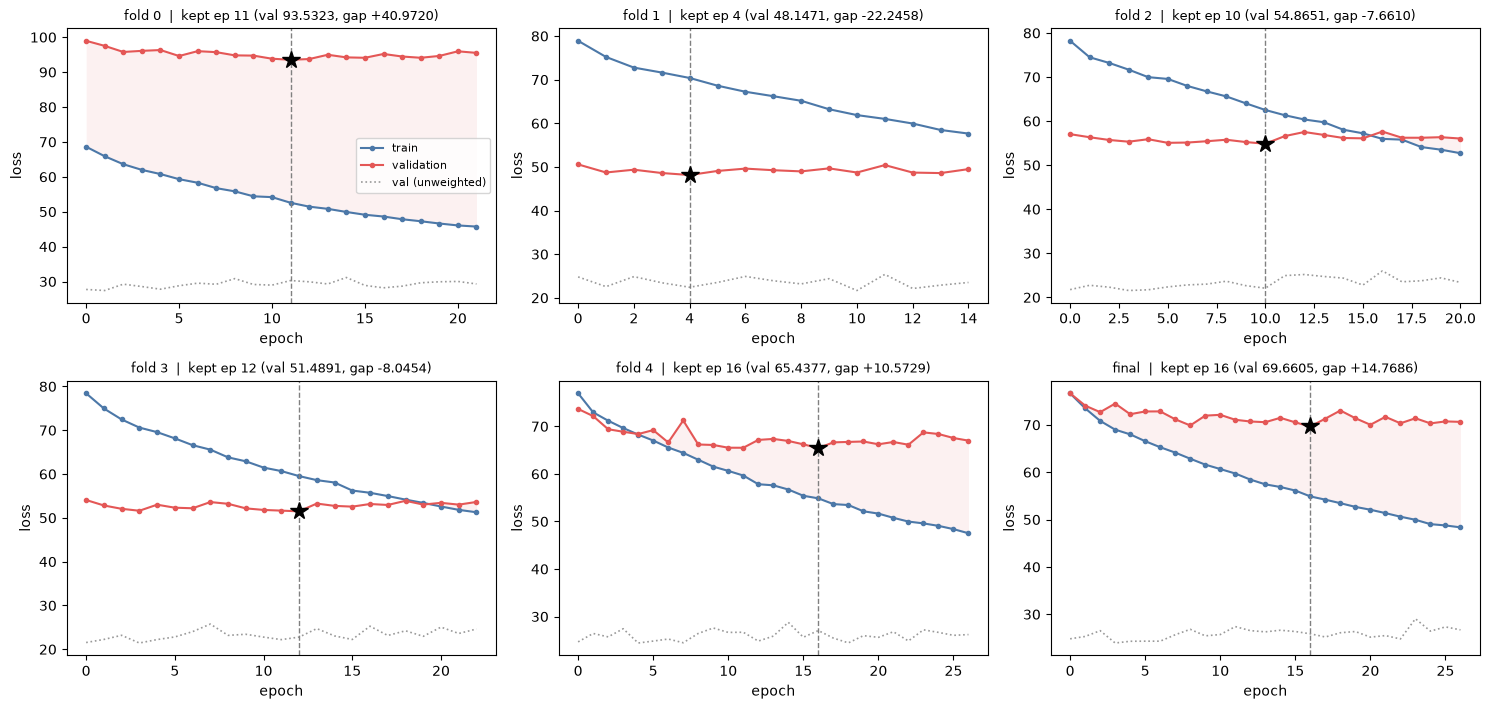

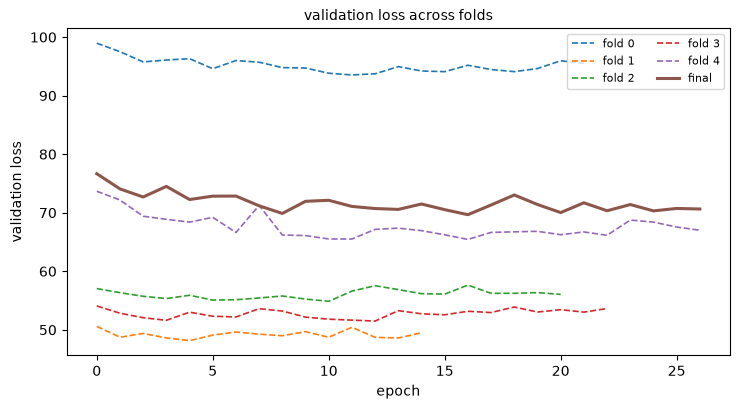

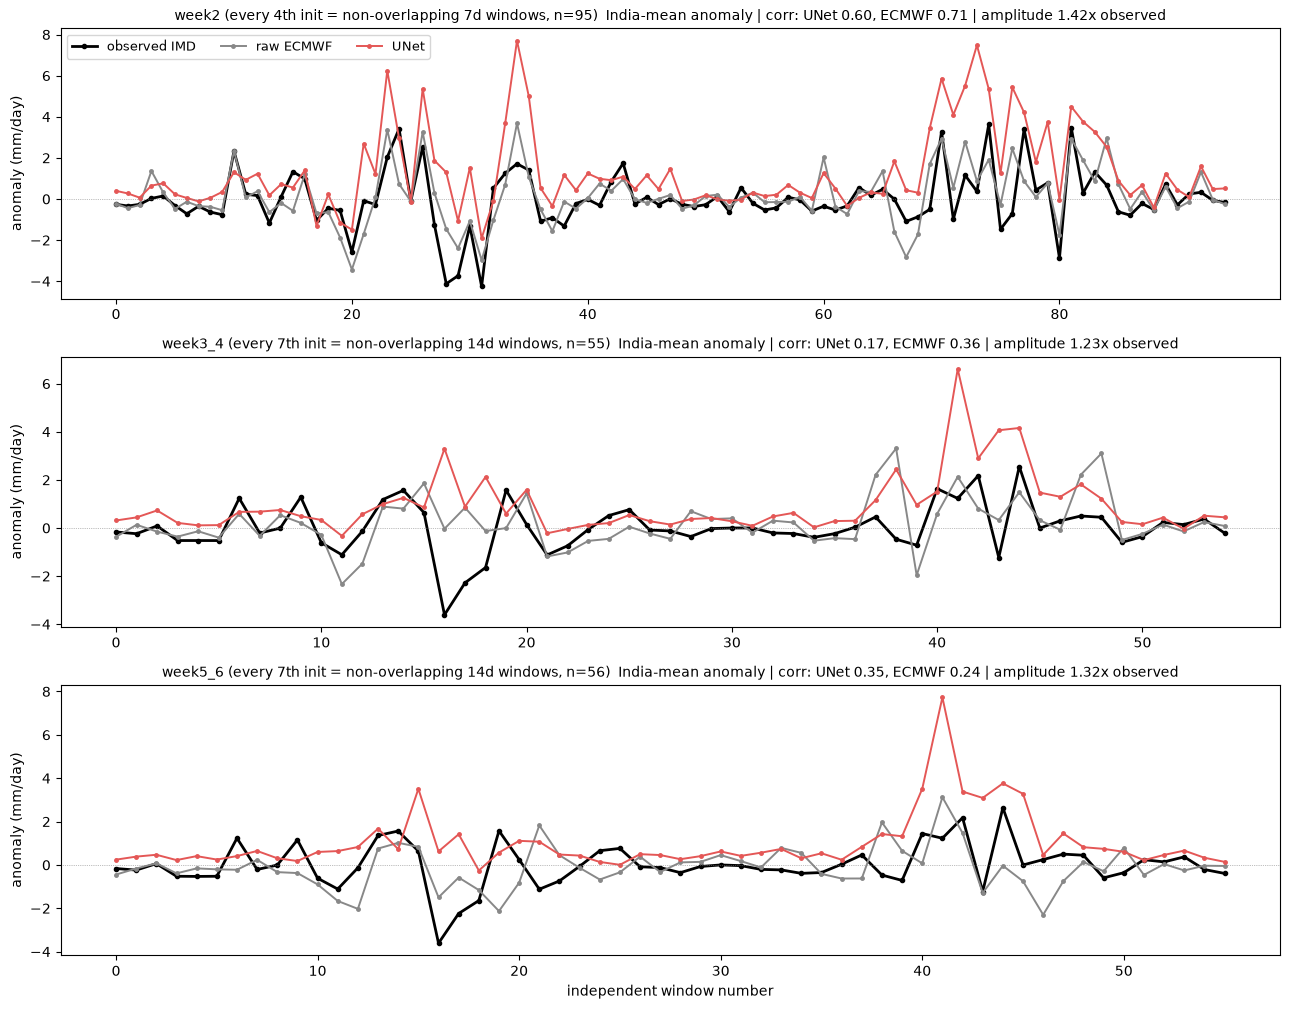

init cadence: 2d


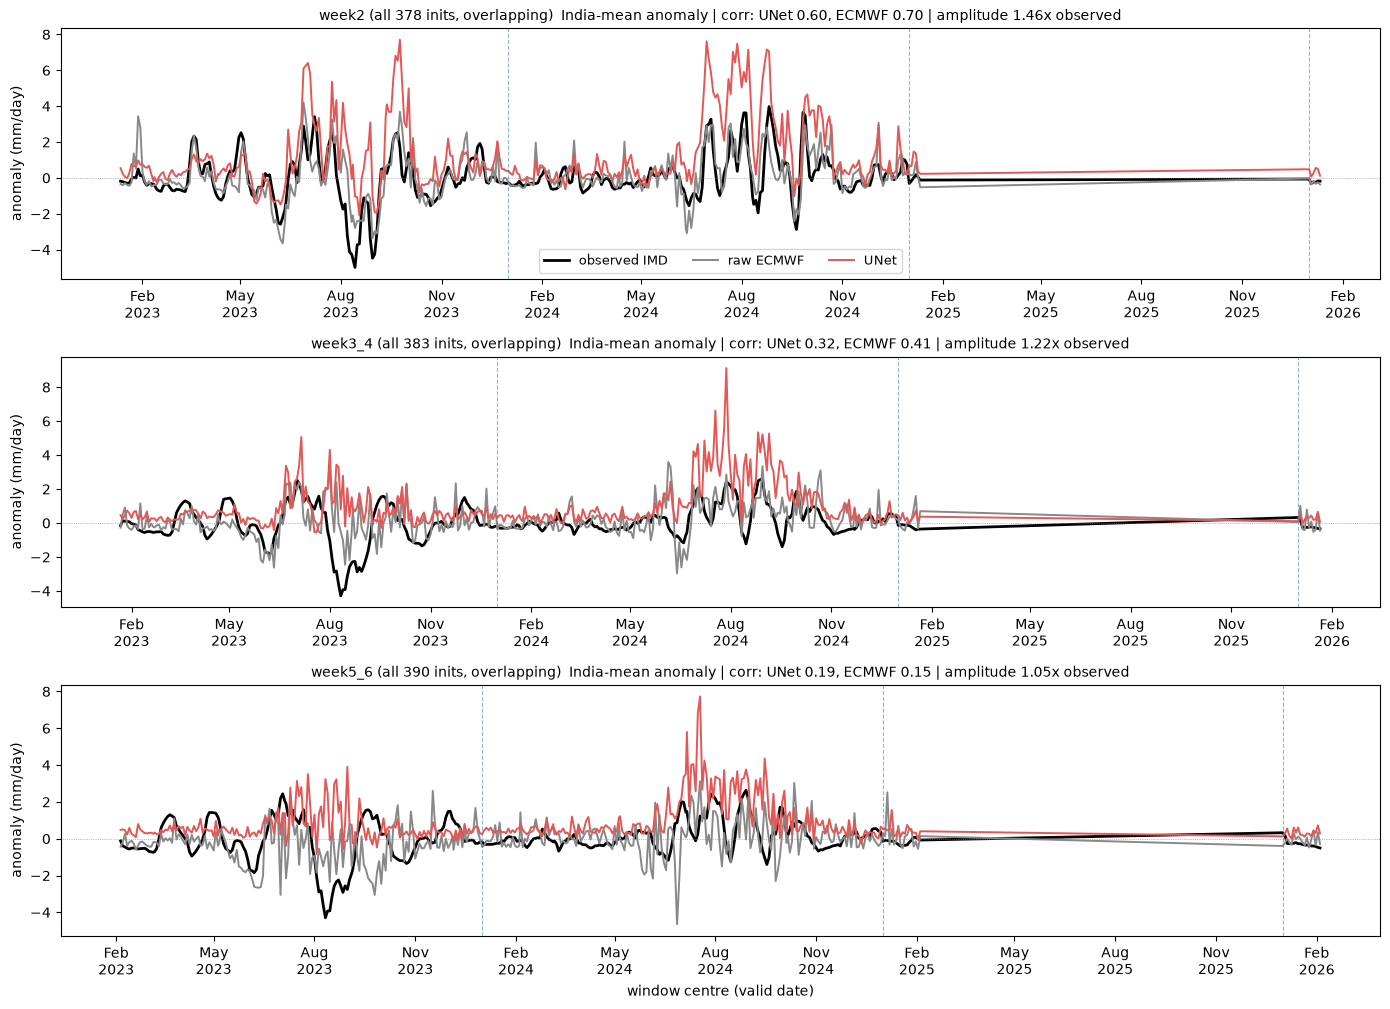

/var/folders/h4/hvzvbp993dx41cy379v1lblm0000gn/T/ipykernel_2290/1050801915.py:174: RuntimeWarning: Mean of empty slice
  prediction_mean = np.nanmean(np.where(is_valid, prediction, np.nan), axis=0)
/var/folders/h4/hvzvbp993dx41cy379v1lblm0000gn/T/ipykernel_2290/1050801915.py:175: RuntimeWarning: Mean of empty slice
  truth_mean = np.nanmean(np.where(is_valid, truth, np.nan), axis=0)


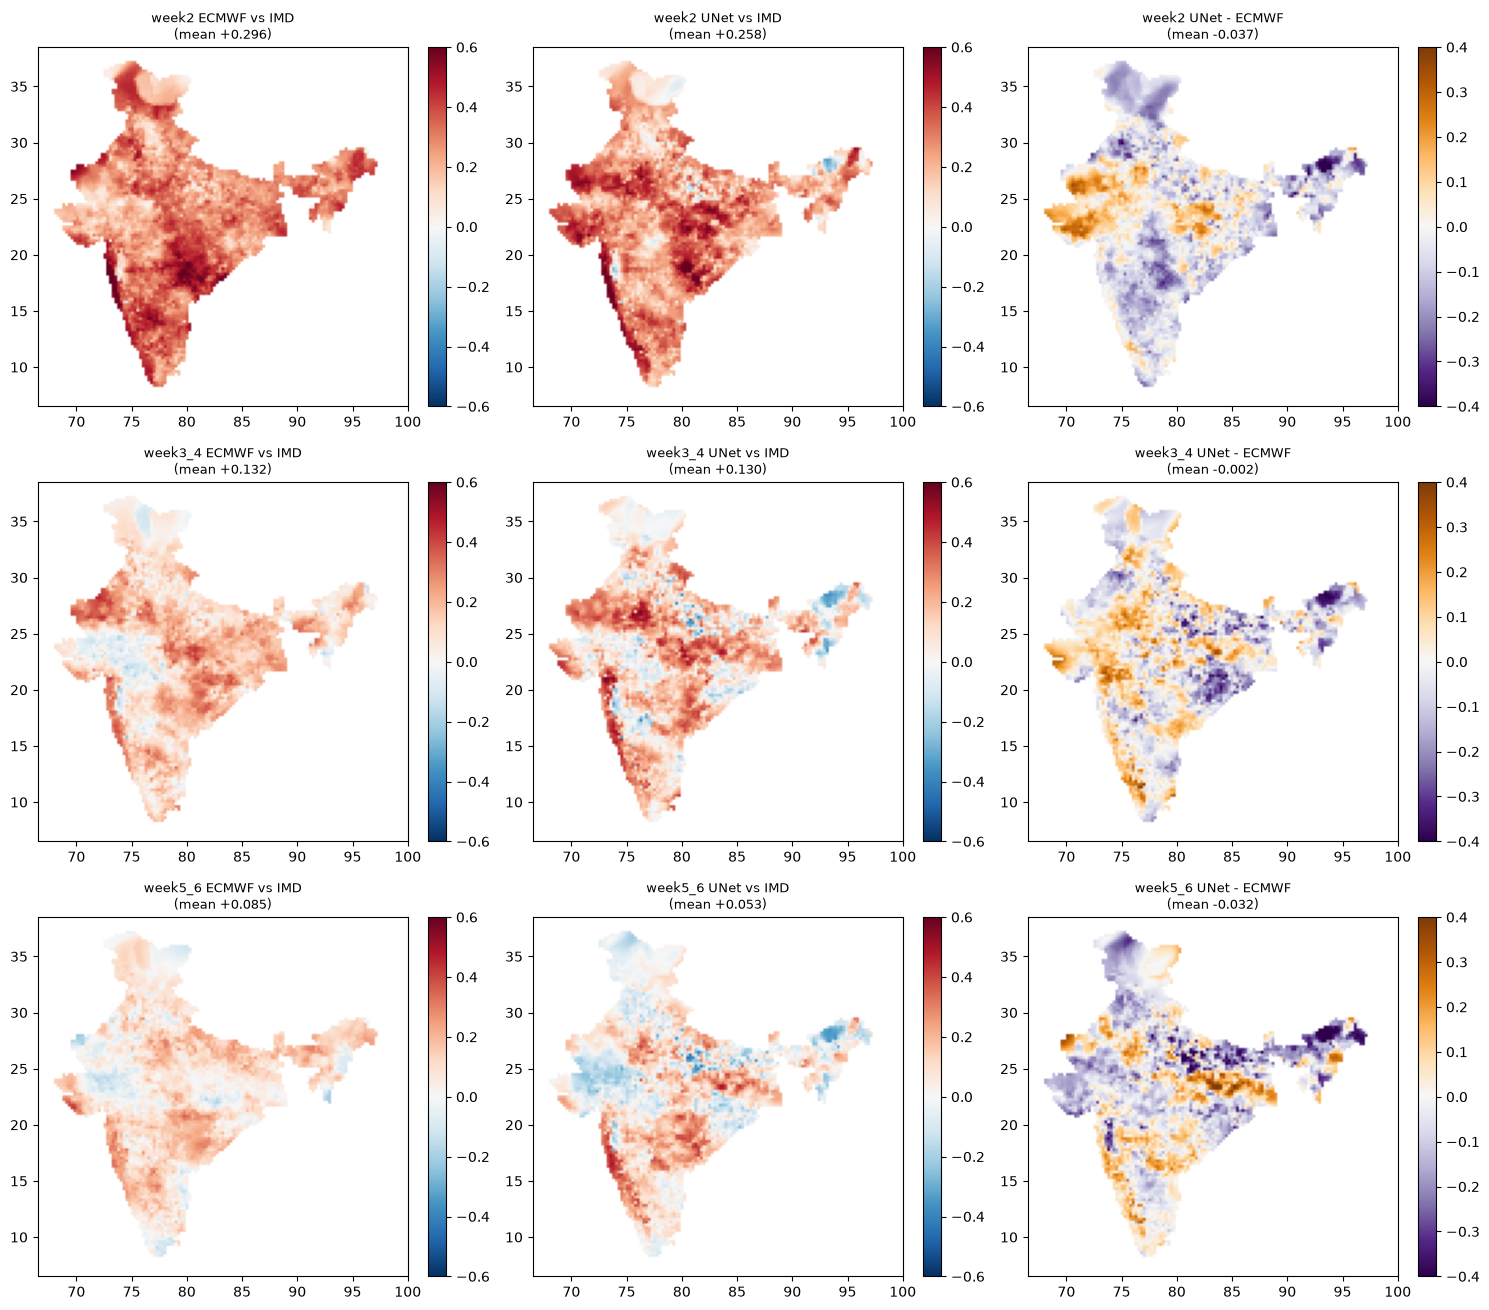

-> learning_curves_prob_d_x2.png (+ _overlay), threeline_strided_prob_d_x2.png, threeline_dates_prob_d_x2.png, corr_maps_prob_d_x2.png/.nc/.npz, rpss_maps_prob_d_x2.png, reliability_prob_d_x2.png


In [20]:
# %%
# ============ CELL 12: PLOTS ============
# Reads the saved _pred.npz. No model rebuild, no inference -- so this cell can
# be re-run and edited freely without touching the GPU.

import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# --- 1. shared helpers ---

def load_test_predictions(pred_path=None):
    """Everything the plots need, as a plain dict."""
    pred_path = pred_path or OUT_MAPS.replace(".nc", "_pred.npz")
    saved = np.load(pred_path)
    return {
        "probabilities": saved["probabilities"] if saved["probabilities"].size else None,
        "anomaly": saved["anomaly"] if saved["anomaly"].size else None,
        "observed_anomaly": saved["observed_anomaly"],
        "observed_class": saved["observed_class"],
        "window_id": saved["window_id"],
    }


def ecmwf_anomaly_on_fine_grid():
    """Raw ECMWF total_precipitation, interpolated to the IMD grid and
    de-seasonalised, for the test rows.

    The reference line in the time-series plot. It gets its OWN climatology
    rather than IMD's, so the ECMWF wet bias cancels and the comparison is
    about phase and amplitude of the anomaly, not about mean state.
    """
    fit_rows = ~is_test
    total_precip = XA[:, varsA.index("total_precipitation")]
    fine = (xr.DataArray(total_precip, dims=("sample", "lat", "lon"),
                         coords={"lat": clatA, "lon": clonA})
            .interp(lat=flat_lat, lon=flat_lon).values.astype(DTYPE))
    return remove_climatology(fine, center_doy, fit_rows)[is_test]


def india_mean(field):
    """Area-mean over the land mask, one value per sample."""
    masked = np.where(land_mask[None], field, np.nan)
    return np.nansum(masked, axis=(1, 2)) / land_mask.sum()


def window_centre_dates():
    """Each sample's window-centre as a real date.

    `sample_year` is the INIT year and `center_doy` is the WINDOW-CENTRE day of
    year, so a late-December init whose window centre falls in January still
    carries the previous year's label. Detect that and roll forward, else the
    point lands a full year early on the axis.
    """
    centre_offsets = np.array([(lo + hi) // 2 for _, lo, hi in WINDOWS])
    rolled_into_next_year = center_doy <= centre_offsets[window_id]
    year_of_centre = sample_year + rolled_into_next_year.astype(int)

    january_first = np.array([np.datetime64(f"{int(v)}-01-01") for v in year_of_centre])
    return january_first + (center_doy - 1).astype("timedelta64[D]")


def init_cadence_days():
    """Median spacing between consecutive initialisations, in days."""
    dates = np.sort(np.unique(window_centre_dates()[window_id == 0]))
    if len(dates) < 3:
        return 2
    gaps = np.diff(dates).astype("timedelta64[D]").astype(int)
    return max(int(np.median(gaps[gaps > 0])), 1)


def draw_map(ax, field, title, cmap, vmin, vmax):
    """One map panel, blanked outside the land mask, with its domain mean."""
    field = field.copy()
    field[~land_mask] = np.nan
    extent = [flat_lon[0], flat_lon[-1], flat_lat[0], flat_lat[-1]]
    image = ax.imshow(field, cmap=cmap, origin="lower", extent=extent,
                      aspect="auto", vmin=vmin, vmax=vmax)
    ax.figure.colorbar(image, ax=ax, fraction=0.046)
    ax.set_title(f"{title}\n(mean {np.nanmean(field[land_mask]):+.3f})", fontsize=9)


# --- 2. India-mean time series ---
# Two views, because consecutive inits overlap heavily: an init on 1 Jul and one
# on 3 Jul both target ~16-29 Jul for week3_4, sharing 13 of 14 days. Scoring is
# unaffected (each is a separately scored forecast), but plotted against a bare
# index one bad fortnight looks like ~20 consecutive failures.
#
#   strided  keep only non-overlapping windows -- each point is independent.
#   dates    real calendar axis, year boundaries marked -- shows the overlap as
#            overlap rather than hiding it, and locates each excursion in a
#            actual monsoon season.
#
# Neither changes the undershoot. The amplitude gap is per-window and is not
# created by overlap; window-averaging is applied to both sides equally. A
# std_ratio near 0.24 is MSE optimality at ACC ~0.24, not a plotting artefact.

def draw_timeseries_panel(ax, rows, x_values, observed, ecmwf, predicted,
                          title, markers=True):
    style = "-o" if markers else "-"
    ax.plot(x_values, observed[rows], style, color="k", lw=2, ms=3, label="observed IMD")
    ax.plot(x_values, ecmwf[rows], style, color="#888", lw=1.4, ms=2.5, label="raw ECMWF")
    ax.plot(x_values, predicted[rows], style, color="#E45756", lw=1.4, ms=2.5, label="UNet")
    ax.axhline(0, color="gray", lw=0.5, ls=":")

    model_corr = np.corrcoef(predicted[rows], observed[rows])[0, 1]
    ecmwf_corr = np.corrcoef(ecmwf[rows], observed[rows])[0, 1]
    amplitude = float(np.std(predicted[rows]) / np.std(observed[rows]))
    ax.set_title(f"{title}  India-mean anomaly | corr: UNet {model_corr:.2f}, "
                 f"ECMWF {ecmwf_corr:.2f} | amplitude {amplitude:.2f}x observed",
                 fontsize=10)
    ax.set_ylabel("anomaly (mm/day)")


def plot_timeseries(predictions, mode="both", tag=None):
    """mode: 'strided' | 'dates' | 'both'."""
    if predictions["anomaly"] is None:
        print("no deterministic head in this run -- skipping time series")
        return
    tag = tag or TAG

    observed = india_mean(predictions["observed_anomaly"])
    ecmwf = india_mean(ecmwf_anomaly_on_fine_grid())
    predicted = india_mean(predictions["anomaly"])
    test_window_id = predictions["window_id"]

    if mode in ("strided", "both"):
        cadence = init_cadence_days()
        fig, axes = plt.subplots(N_WINDOWS, 1, figsize=(13, 3.4 * N_WINDOWS))
        for w, ax in enumerate(np.atleast_1d(axes)):
            _, first_lead, last_lead = WINDOWS[w]
            window_length = last_lead - first_lead + 1
            stride = max(int(round(window_length / cadence)), 1)
            rows = np.where(test_window_id == w)[0][::stride]
            draw_timeseries_panel(
                ax, rows, np.arange(len(rows)), observed, ecmwf, predicted,
                f"{window_names[w]} (every {stride}th init = non-overlapping "
                f"{window_length}d windows, n={len(rows)})")
            if w == 0:
                ax.legend(ncol=3, fontsize=9)
        np.atleast_1d(axes)[-1].set_xlabel("independent window number")
        fig.tight_layout()
        fig.savefig(f"threeline_strided_{tag}.png", dpi=140)
        plt.show()
        print(f"init cadence: {cadence}d")

    if mode in ("dates", "both"):
        dates = window_centre_dates()[is_test]
        fig, axes = plt.subplots(N_WINDOWS, 1, figsize=(14, 3.4 * N_WINDOWS))
        for w, ax in enumerate(np.atleast_1d(axes)):
            rows = np.where(test_window_id == w)[0]
            rows = rows[np.argsort(dates[rows])]
            draw_timeseries_panel(
                ax, rows, dates[rows], observed, ecmwf, predicted,
                f"{window_names[w]} (all {len(rows)} inits, overlapping)", markers=False)
            for year_start in np.unique(dates[rows].astype("datetime64[Y]"))[1:]:
                ax.axvline(year_start.astype("datetime64[D]"), color="steelblue",
                           lw=0.8, ls="--", alpha=0.6)
            ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
            if w == 0:
                ax.legend(ncol=3, fontsize=9)
        np.atleast_1d(axes)[-1].set_xlabel("window centre (valid date)")
        fig.tight_layout()
        fig.savefig(f"threeline_dates_{tag}.png", dpi=140)
        plt.show()


# --- 3. deterministic correlation maps ---

def correlation_map(prediction, truth, is_valid):
    """Per-cell temporal correlation over the selected rows."""
    with np.errstate(invalid="ignore", divide="ignore"):
        prediction_mean = np.nanmean(np.where(is_valid, prediction, np.nan), axis=0)
        truth_mean = np.nanmean(np.where(is_valid, truth, np.nan), axis=0)
        covariance = np.nansum(np.where(
            is_valid, (prediction - prediction_mean) * (truth - truth_mean), np.nan), axis=0)
        spread = np.sqrt(
            np.nansum(np.where(is_valid, (prediction - prediction_mean) ** 2, np.nan), axis=0)
            * np.nansum(np.where(is_valid, (truth - truth_mean) ** 2, np.nan), axis=0))
        return np.where(spread > 0, covariance / spread, np.nan)


def plot_correlation_maps(predictions, tag=None):
    """UNet vs ECMWF vs their difference, per window. Saved as png + nc + npz."""
    if predictions["anomaly"] is None:
        return
    tag = tag or TAG

    observed = predictions["observed_anomaly"]
    ecmwf = ecmwf_anomaly_on_fine_grid()
    predicted = predictions["anomaly"]
    test_window_id = predictions["window_id"]
    is_valid = valid_observation_mask(is_test)

    saved_maps = {}
    fig, axes = plt.subplots(N_WINDOWS, 3, figsize=(15, 4.4 * N_WINDOWS))
    for w in range(N_WINDOWS):
        rows = test_window_id == w
        name = window_names[w]
        ecmwf_corr = correlation_map(ecmwf[rows], observed[rows], is_valid[rows])
        model_corr = correlation_map(predicted[rows], observed[rows], is_valid[rows])

        saved_maps[f"{name}_corr_ecmwf"] = ecmwf_corr
        saved_maps[f"{name}_corr_unet"] = model_corr
        saved_maps[f"{name}_corr_diff"] = model_corr - ecmwf_corr

        panels = [(ecmwf_corr, "ECMWF vs IMD", "RdBu_r", 0.6),
                  (model_corr, "UNet vs IMD", "RdBu_r", 0.6),
                  (model_corr - ecmwf_corr, "UNet - ECMWF", "PuOr_r", 0.4)]
        for column, (field, label, cmap, limit) in enumerate(panels):
            draw_map(np.atleast_2d(axes)[w, column], field,
                     f"{name} {label}", cmap, -limit, limit)

    fig.tight_layout()
    fig.savefig(f"corr_maps_{tag}.png", dpi=130)
    plt.show()

    write_netcdf(xr.Dataset({k: (("lat", "lon"), v) for k, v in saved_maps.items()},
                            coords={"lat": flat_lat, "lon": flat_lon}), f"corr_maps_{tag}.nc")
    np.savez_compressed(f"corr_maps_{tag}.npz", lat=flat_lat, lon=flat_lon,
                        mask=land_mask, **saved_maps)


# --- 4. probabilistic diagnostics ---

def plot_rpss_maps(predictions, tag=None):
    """RPSS against climatology, and the mean forecast probability of the wet
    tercile -- the second panel catches a model that buys RPSS by leaning
    permanently wet or dry somewhere."""
    if predictions["probabilities"] is None:
        return
    tag = tag or TAG

    probabilities = predictions["probabilities"]
    observed_class = predictions["observed_class"]
    test_window_id = predictions["window_id"]
    is_valid = valid_observation_mask(is_test)

    fig, axes = plt.subplots(N_WINDOWS, 2, figsize=(11, 4.4 * N_WINDOWS))
    for w in range(N_WINDOWS):
        rows = test_window_id == w
        rpss_field = rpss(probabilities[rows], observed_class[rows], is_valid[rows])
        wet_probability = np.nanmean(
            np.where(is_valid[rows], probabilities[rows][:, 2], np.nan), axis=0)

        draw_map(np.atleast_2d(axes)[w, 0], rpss_field,
                 f"{window_names[w]} RPSS vs climatology", "RdBu_r", -0.3, 0.3)
        draw_map(np.atleast_2d(axes)[w, 1], wet_probability,
                 f"{window_names[w]} mean P(wet tercile)", "BrBG", 0.2, 0.47)

    fig.tight_layout()
    fig.savefig(f"rpss_maps_{tag}.png", dpi=130)
    plt.show()


def plot_reliability(predictions, tag=None, min_samples_per_bin=50):
    """Of the times the model said "X% chance of wet", how often was it wet?
    On the diagonal = calibrated. Below = overconfident."""
    if predictions["probabilities"] is None:
        return
    tag = tag or TAG

    probabilities = predictions["probabilities"]
    observed_class = predictions["observed_class"]
    test_window_id = predictions["window_id"]
    is_valid = valid_observation_mask(is_test)
    bin_edges = np.linspace(0, 1, 11)

    fig, axes = plt.subplots(1, N_WINDOWS, figsize=(4.6 * N_WINDOWS, 4.4))
    for w, ax in enumerate(np.atleast_1d(axes)):
        rows = test_window_id == w
        forecast_wet = probabilities[rows][:, 2][is_valid[rows]]
        observed_wet = (observed_class[rows] == 2)[is_valid[rows]].astype(float)

        bin_forecast, bin_observed = [], []
        for lower, upper in zip(bin_edges[:-1], bin_edges[1:]):
            in_bin = (forecast_wet >= lower) & (forecast_wet < upper)
            if in_bin.sum() > min_samples_per_bin:
                bin_forecast.append(forecast_wet[in_bin].mean())
                bin_observed.append(observed_wet[in_bin].mean())

        ax.plot([0, 1], [0, 1], "k--", lw=1, label="perfect")
        ax.plot(bin_forecast, bin_observed, "o-", color="#E45756", label="model")
        ax.axhline(1 / 3, color="gray", lw=0.5, ls=":")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xlabel("forecast P(wet)")
        ax.set_ylabel("observed frequency")
        ax.set_title(window_names[w])
        ax.legend(fontsize=8)

    fig.tight_layout()
    fig.savefig(f"reliability_{tag}.png", dpi=130)
    plt.show()


# --- 5. learning curves ---

def load_training_history(tag=None):
    """-> {run label: list of per-epoch dicts}, for every fold plus the final fit.

    Read from disk rather than passed in, so this plots correctly after a
    resumed run where some folds were never retrained in this session.
    """
    tag = tag or TAG
    out_path = OUT_MAPS if tag == TAG else f"unet_{tag}.nc"
    histories = {}

    folds_path = out_path.replace(".nc", "_folds.json")
    if os.path.exists(folds_path):
        with open(folds_path) as f:
            saved = json.load(f)
        for key, fold in sorted(saved.items(), key=lambda kv: int(kv[0])):
            if fold.get("history"):
                histories[f"fold {key}"] = fold["history"]

    final_path = out_path.replace(".nc", "_history.json")
    if os.path.exists(final_path):
        with open(final_path) as f:
            histories["final"] = json.load(f)

    return histories


def draw_learning_curve(ax, history, label):
    """Train and validation loss per epoch, with the kept epoch marked.

    Read the GAP, not either curve alone. Both fall while the model is still
    learning generalisable structure; the epoch where validation flattens or
    turns up while training keeps dropping is where it starts memorising 20
    years of noise, and everything after it is bought back by early stopping.
    """
    epochs = [h["epoch"] for h in history]
    train = np.array([h["train"] for h in history])
    val = np.array([h["val"] for h in history])

    ax.plot(epochs, train, "-o", color="#4C78A8", lw=1.5, ms=3, label="train")
    ax.plot(epochs, val, "-o", color="#E45756", lw=1.5, ms=3, label="validation")

    # Under the weighted loss this is a different quantity from the two above,
    # so it is drawn faint: it is context, not something being minimised, and
    # it is expected to drift upward as the model gains amplitude.
    monitor = np.array([h.get("val_monitor", np.nan) for h in history])
    if np.isfinite(monitor).any() and not np.allclose(monitor, val, equal_nan=True):
        ax.plot(epochs, monitor, color="#999999", lw=1.2, ls=":",
                label="val (unweighted)")

    best = int(np.nanargmin(val))
    ax.axvline(epochs[best], color="gray", lw=1, ls="--")
    ax.plot(epochs[best], val[best], "*", color="k", ms=13, zorder=5)
    ax.fill_between(epochs, train, val, where=val >= train,
                    color="#E45756", alpha=0.08, lw=0)

    ax.set_title(f"{label}  |  kept ep {epochs[best]} (val {val[best]:.4f}, "
                 f"gap {val[best] - train[best]:+.4f})", fontsize=9)
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")


def plot_learning_curves(tag=None, max_columns=3):
    """One panel per fold plus the final fit, and an overlay of all val curves."""
    tag = tag or TAG
    histories = load_training_history(tag)
    if not histories:
        print("no training history saved -- skipping learning curves")
        return

    n_runs = len(histories)
    n_columns = min(n_runs, max_columns)
    n_rows = int(np.ceil(n_runs / n_columns))

    fig, axes = plt.subplots(n_rows, n_columns, figsize=(5.0 * n_columns, 3.6 * n_rows),
                             squeeze=False)
    for ax, (label, history) in zip(axes.ravel(), histories.items()):
        draw_learning_curve(ax, history, label)
    for ax in axes.ravel()[n_runs:]:
        ax.axis("off")
    axes.ravel()[0].legend(fontsize=8)

    fig.tight_layout()
    fig.savefig(f"learning_curves_{tag}.png", dpi=140)
    plt.show()

    # Overlay: are the folds behaving consistently, or is one of them diverging?
    fig, ax = plt.subplots(figsize=(7.5, 4.2))
    for label, history in histories.items():
        style = "-" if label == "final" else "--"
        width = 2.2 if label == "final" else 1.2
        ax.plot([h["epoch"] for h in history], [h["val"] for h in history],
                style, lw=width, label=label)
    ax.set_xlabel("epoch")
    ax.set_ylabel("validation loss")
    ax.set_title("validation loss across folds", fontsize=10)
    ax.legend(fontsize=8, ncol=2)
    fig.tight_layout()
    fig.savefig(f"learning_curves_overlay_{tag}.png", dpi=140)
    plt.show()


def plot_all(pred_path=None, tag=None):
    plot_learning_curves(tag=tag)
    predictions = load_test_predictions(pred_path)
    plot_timeseries(predictions, tag=tag)
    plot_correlation_maps(predictions, tag=tag)
    plot_rpss_maps(predictions, tag=tag)
    plot_reliability(predictions, tag=tag)
    print(f"-> learning_curves_{tag or TAG}.png (+ _overlay), "
          f"threeline_strided_{tag or TAG}.png, threeline_dates_{tag or TAG}.png, "
          f"corr_maps_{tag or TAG}.png/.nc/.npz, rpss_maps_{tag or TAG}.png, "
          f"reliability_{tag or TAG}.png")


plot_all()

In [23]:
# %%
# ============ CELL 13: RAW mm/day RECONSTRUCTION ============
# The anomaly plots answer "does the model beat climatology". This one answers
# "what does the forecast actually look like". Read the health warning in
# plot_raw_timeseries before quoting any correlation from here.

def imd_climatology_for_final_model():
    """The IMD day-of-year climatology the FINAL model's anomalies were taken
    against -- refitted on exactly the rows cell 11 trained on.

    It has to be the same fit rows, not all non-test years. Cell 11 holds the
    last two non-test years out for early stopping and excludes them from the
    climatology too, so using a different set here would leave a residual
    seasonal signal in the reconstruction that the model never saw.
    """
    early_stop_years = NONTEST_YEARS[-2:]
    val_rows = np.isin(sample_year, early_stop_years) & ~is_test
    fit_rows = (~is_test) & ~val_rows
    return climatology_by_day_of_year(y, center_doy, fit_rows, CLIM_WINDOW_DAYS)


def reconstruct_raw_rainfall(pred_path=None):
    """-> dict of raw mm/day fields for the test rows.

    observed comes straight from the cache rather than from anomaly + climatology:
    it is the ground truth, and reconstructing it would only add rounding.
    Prediction is clipped at zero -- an anomaly below minus the climatology
    implies negative rainfall, which is not a thing.
    """
    predictions = load_test_predictions(pred_path)
    if predictions["anomaly"] is None:
        raise RuntimeError("this run has no deterministic head to reconstruct")

    climatology = imd_climatology_for_final_model()
    test_climatology = climatology[center_doy[is_test] - 1]

    ecmwf_raw = (xr.DataArray(XA[:, varsA.index("total_precipitation")],
                              dims=("sample", "lat", "lon"),
                              coords={"lat": clatA, "lon": clonA})
                 .interp(lat=flat_lat, lon=flat_lon).values.astype(DTYPE))[is_test]

    return {
        "observed": np.asarray(y)[is_test],
        "predicted": np.clip(predictions["anomaly"] + test_climatology, 0, None),
        "ecmwf": np.clip(ecmwf_raw, 0, None),
        "climatology": test_climatology,
        "window_id": predictions["window_id"],
    }


def plot_raw_timeseries(pred_path=None, tag=None, mode="strided"):
    """India-mean rainfall in mm/day: observed, ECMWF, UNet, and climatology.

    HEALTH WARNING, and it is the whole reason the climatology line is drawn.
    A correlation computed on raw rainfall is dominated by the annual cycle --
    every model that knows roughly when the monsoon happens scores high, and
    a raw-value correlation of 0.85 can coexist with a forecast that never
    exceeds 60% of the observed peak. The climatology line is what you get from
    a calendar and nothing else, so r_clim is the floor: only the amount by
    which a model clears it is skill. That difference is what the anomaly plots
    show directly, which is why they remain the scoring view.
    """
    tag = tag or TAG
    raw = reconstruct_raw_rainfall(pred_path)
    observed, predicted = india_mean(raw["observed"]), india_mean(raw["predicted"])
    ecmwf, climatology = india_mean(raw["ecmwf"]), india_mean(raw["climatology"])
    test_window_id = raw["window_id"]
    cadence = init_cadence_days()

    fig, axes = plt.subplots(N_WINDOWS, 1, figsize=(14, 3.6 * N_WINDOWS))
    for w, ax in enumerate(np.atleast_1d(axes)):
        _, first_lead, last_lead = WINDOWS[w]
        rows = np.where(test_window_id == w)[0]
        if mode == "strided":
            stride = max(int(round((last_lead - first_lead + 1) / cadence)), 1)
            rows = rows[::stride]
        x = np.arange(len(rows))

        ax.plot(x, observed[rows], "-", color="k", lw=2, label="observed IMD")
        ax.plot(x, ecmwf[rows], "-", color="#888", lw=1.3, label="raw ECMWF")
        ax.plot(x, predicted[rows], "-", color="#E45756", lw=1.4, label="UNet")
        ax.plot(x, climatology[rows], "-", color="#4C78A8", lw=1.2, ls="--",
                label="climatology (calendar only)")

        def corr(series):
            return np.corrcoef(series[rows], observed[rows])[0, 1]

        amplitude = float(np.std(predicted[rows]) / np.std(observed[rows]))
        ax.set_title(f"{window_names[w]}  India-mean rainfall (mm/day), n={len(rows)}  |  "
                     f"r: UNet {corr(predicted):.2f}, ECMWF {corr(ecmwf):.2f}, "
                     f"CLIMATOLOGY {corr(climatology):.2f}  |  "
                     f"UNet amplitude {amplitude:.2f}x observed", fontsize=9)
        ax.set_ylabel("rainfall (mm/day)")
        ax.set_ylim(bottom=0)
        if w == 0:
            ax.legend(ncol=4, fontsize=8)

    np.atleast_1d(axes)[-1].set_xlabel("independent window number")
    fig.tight_layout()
    fig.savefig(f"raw_timeseries_{tag}.png", dpi=140)
    plt.show()

    print(f"-> raw_timeseries_{tag}.png")
    print("   r values above are inflated by the annual cycle; compare each "
          "against the climatology line, not against zero.")


plot_raw_timeseries()

FileNotFoundError: [Errno 2] No such file or directory: 'unet_prob_d_x2_pred.npz'